# AI Hospital Readmission Risk & Care Management Platform

### Industry: Healthcare

Healthcare is the industry in which hospitals, clinics, and other healthcare organizations provide patient care, diagnosis, treatment, monitoring, and follow-up services.

In a hospital environment, large amounts of operational and clinical information are generated through patient admissions, diagnoses, laboratory tests, medications, procedures, hospital stays, and discharge activities.

### Domain: Hospital Readmission & Care Management

Hospital readmission refers to a patient returning to the hospital after a previous hospital stay.

Our specific domain is **30-Day Hospital Readmission Risk**.

#### 1.Code

#### Import Required Python Modules


In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import mysql.connector

In [79]:
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="hospital_readmission"
)

connection

In [86]:
df_source = pd.read_sql(
    "SELECT * FROM diabetic_data",
    connection
)

df_source


C:\Users\chinn\AppData\Local\Temp\ipykernel_3800\4180335439.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_source = pd.read_sql(


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide_metformin,glipizide_metformin,glimepiride_pioglitazone,metformin_rosiglitazone,metformin_pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [87]:
ids_mapping_source = pd.read_sql(
    "SELECT * FROM ids_mapping_raw",
    connection
)

ids_mapping_source

C:\Users\chinn\AppData\Local\Temp\ipykernel_3800\1447518689.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ids_mapping_source = pd.read_sql(


,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
...,...,...
62,22,Transfer from hospital inpt/same fac reslt in...
63,23,Born inside this hospital
64,24,Born outside this hospital
65,25,Transfer from Ambulatory Surgery Center


In [88]:
#### Verify the Loaded Dataset
df_source.shape


(101766, 50)

In [89]:
df_source.columns


Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide_metformin', 'glipizide_metformin',
       'glimepiride_pioglitazone', 'metformin_rosiglitazone',
       'metformin_pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [90]:
df_source.dtypes

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

### 2.5 Create a Working Copy for Analysis

The dataset loaded from MySQL represents the original source data. 
To protect the originality and integrity of the source dataset, we will not modify `df_source` directly.

A separate working copy will be created for validation, exploratory analysis, data preparation, and later feature engineering.

#### Data Handling Principle

**Original Source → Preserved**

`df_source` will remain unchanged throughout the project.

**Working Data → Analysis**

`df_working` will be used for validation and subsequent analytical activities.

This approach allows us to always return to the original source data if a transformation or decision needs to be reviewed.

In [91]:
df_working = df_source.copy()

df_working.shape

(101766, 50)

In [92]:
ids_mapping_working = ids_mapping_source.copy()

ids_mapping_working

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
...,...,...
62,22,Transfer from hospital inpt/same fac reslt in...
63,23,Born inside this hospital
64,24,Born outside this hospital
65,25,Transfer from Ambulatory Surgery Center


#### Data Validation
The hospital encounter data has been successfully retrieved from the MySQL database and copied into `df_working`.

Before performing exploratory data analysis, we need to verify whether each field is appropriate for its intended business meaning and analytical use.

The validation process is performed column by column rather than relying only on automated data-qu

In [93]:
df_working.shape

(101766, 50)

In [94]:
df_working.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide_metformin', 'glipizide_metformin',
       'glimepiride_pioglitazone', 'metformin_rosiglitazone',
       'metformin_pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [95]:
df_working.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

#### Duplicate Validation
A duplicate hospital encounter could cause the same clinical event to be counted more than once.

This could distort readmission rates, distributions, business insights, and eventually model training.

Therefore, we check:

- Exact duplicate records
- Duplicate `encounter_id`
- Patient-level repetition separately


In [97]:
duplicate_validation = pd.Series({
    "exact_duplicate_rows": df_working.duplicated().sum(),
    "duplicate_encounter_ids": df_working["encounter_id"].duplicated().sum(),
    "unique_encounters": df_working["encounter_id"].nunique(),
    "unique_patients": df_working["patient_nbr"].nunique()
})

duplicate_validation.to_frame("value")

,value
exact_duplicate_rows,0
duplicate_encounter_ids,0
unique_encounters,101766
unique_patients,71518


#### Missing Value Validation





In [98]:
missing_nan = pd.DataFrame({
    "missing_count": df_working.isna().sum(),
    "missing_percentage": (df_working.isna().mean() * 100).round(2)
})

missing_nan.sort_values("missing_count", ascending=False)

,missing_count,missing_percentage
encounter_id,0,0.0
troglitazone,0,0.0
chlorpropamide,0,0.0
glimepiride,0,0.0
acetohexamide,0,0.0
glipizide,0,0.0
glyburide,0,0.0
tolbutamide,0,0.0
pioglitazone,0,0.0
rosiglitazone,0,0.0


In [99]:
missing_question_mark = pd.DataFrame({
    "question_mark_count": (df_working == "?").sum(),
    "question_mark_percentage": ((df_working == "?").mean() * 100).round(2)
})

missing_question_mark.sort_values("question_mark_count", ascending=False)

,question_mark_count,question_mark_percentage
weight,98569,96.86
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02
encounter_id,0,0.00
tolazamide,0,0.00
glyburide,0,0.00


In [100]:
missing_validation = pd.DataFrame({
    "data_type": df_working.dtypes.astype(str),
    "NaN_count": df_working.isna().sum(),
    "NaN_percentage": (df_working.isna().mean() * 100).round(2),
    "question_mark_count": (df_working == "?").sum(),
    "question_mark_percentage": ((df_working == "?").mean() * 100).round(2)
})

missing_validation.sort_values(
    ["NaN_count", "question_mark_count"],
    ascending=False
)

,data_type,NaN_count,NaN_percentage,question_mark_count,question_mark_percentage
weight,object,0,0.0,98569,96.86
medical_specialty,object,0,0.0,49949,49.08
payer_code,object,0,0.0,40256,39.56
race,object,0,0.0,2273,2.23
diag_3,object,0,0.0,1423,1.40
diag_2,object,0,0.0,358,0.35
diag_1,object,0,0.0,21,0.02
encounter_id,int64,0,0.0,0,0.00
patient_nbr,int64,0,0.0,0,0.00
gender,object,0,0.0,0,0.00


#### Column-by-Column Data Validation
#### Identifier Validation

We start with the two identifier columns:

1. encounter_id → uniquely identifies a hospital encounter.
2. patient_nbr → identifies the patient and may legitimately repeat because one patient can have multiple encounters.

In [101]:
### encounter_id
encounter_id_validation = pd.DataFrame({
    "column": ["encounter_id"],
    "data_type": [df_working["encounter_id"].dtype],
    "missing_values": [df_working["encounter_id"].isna().sum()],
    "unique_values": [df_working["encounter_id"].nunique()],
    "duplicate_values": [df_working["encounter_id"].duplicated().sum()],
    "minimum": [df_working["encounter_id"].min()],
    "maximum": [df_working["encounter_id"].max()]
})

encounter_id_validation

,column,data_type,missing_values,unique_values,duplicate_values,minimum,maximum
0,encounter_id,int64,0,101766,0,12522,443867222


In [102]:
### patient_nbr
patient_nbr_validation = pd.DataFrame({
    "column": ["patient_nbr"],
    "data_type": [df_working["patient_nbr"].dtype],
    "missing_values": [df_working["patient_nbr"].isna().sum()],
    "unique_values": [df_working["patient_nbr"].nunique()],
    "duplicate_values": [df_working["patient_nbr"].duplicated().sum()],
    "minimum": [df_working["patient_nbr"].min()],
    "maximum": [df_working["patient_nbr"].max()]
})

patient_nbr_validation

,column,data_type,missing_values,unique_values,duplicate_values,minimum,maximum
0,patient_nbr,int64,0,71518,30248,135,189502619


### race
The hospital system records the patient's race as a categorical demographic attribute. We need to verify that the column contains expected categories, identify missing/unavailable values, and make sure there are no unexpected values.

In [103]:
race_validation = pd.DataFrame({
    "column": ["race"],
    "data_type": [df_working["race"].dtype],
    "missing_values": [df_working["race"].isna().sum()],
    "question_mark_values": [(df_working["race"] == "?").sum()],
    "unique_values": [df_working["race"].nunique(dropna=False)]
})

race_validation

,column,data_type,missing_values,question_mark_values,unique_values
0,race,object,0,2273,6


In [104]:
race_values = (
    df_working["race"]
    .value_counts(dropna=False)
    .rename_axis("race")
    .reset_index(name="record_count")
)

race_values

,race,record_count
0,Caucasian,76099
1,AfricanAmerican,19210
2,?,2273
3,Hispanic,2037
4,Other,1506
5,Asian,641


### gender
Gender is recorded for each hospital encounter. We need to verify that the values correspond to meaningful categories and identify any abnormal/unknown records.

In [105]:
gender_validation = pd.DataFrame({
    "column": ["gender"],
    "data_type": [df_working["gender"].dtype],
    "missing_values": [df_working["gender"].isna().sum()],
    "question_mark_values": [(df_working["gender"] == "?").sum()],
    "unique_values": [df_working["gender"].nunique(dropna=False)]
})

gender_validation

,column,data_type,missing_values,question_mark_values,unique_values
0,gender,object,0,0,3


In [106]:
gender_values = (
    df_working["gender"]
    .value_counts(dropna=False)
    .rename_axis("gender")
    .reset_index(name="record_count")
)

gender_values

,gender,record_count
0,Female,54708
1,Male,47055
2,Unknown/Invalid,3


### age
Age is an important demographic variable for readmission analysis. However, this dataset does not provide exact patient ages; it stores age as 10-year intervals. Therefore, validation must check whether the observed intervals follow the intended representation.

In [107]:
age_validation = pd.DataFrame({
    "column": ["age"],
    "data_type": [df_working["age"].dtype],
    "missing_values": [df_working["age"].isna().sum()],
    "question_mark_values": [(df_working["age"] == "?").sum()],
    "unique_values": [df_working["age"].nunique(dropna=False)]
})

age_validation

,column,data_type,missing_values,question_mark_values,unique_values
0,age,object,0,0,10


In [108]:
age_values = (
    df_working["age"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("age_group")
    .reset_index(name="record_count")
)

age_values

,age_group,record_count
0,[0-10),161
1,[10-20),691
2,[20-30),1657
3,[30-40),3775
4,[40-50),9685
5,[50-60),17256
6,[60-70),22483
7,[70-80),26068
8,[80-90),17197
9,[90-100),2793


In [109]:
### Demographic Validation Summary
demographic_validation_summary = pd.DataFrame({
    "column": ["race", "gender", "age"],
    "intended_role": [
        "Patient demographic category",
        "Patient demographic category",
        "Patient age group"
    ],
    "source_representation": [
        "Categorical",
        "Categorical",
        "10-year categorical intervals"
    ],
    "validation_focus": [
        "Expected categories and missing representation",
        "Expected categories and unknown values",
        "Expected age-group intervals"
    ],
    "validation_status": [
        "Valid; missing represented by ?",
        "Valid; Unknown/Invalid present",
        "Valid; grouped age representation"
    ]
})

demographic_validation_summary

,column,intended_role,source_representation,validation_focus,validation_status
0,race,Patient demographic category,Categorical,Expected categories and missing representation,Valid; missing represented by ?
1,gender,Patient demographic category,Categorical,Expected categories and unknown values,Valid; Unknown/Invalid present
2,age,Patient age group,10-year categorical intervals,Expected age-group intervals,Valid; grouped age representation


### Hospital Admission Columns
In this hospital readmission project, the patient's admission journey is described through three ID columns: admission_type_id, discharge_disposition_id, and admission_source_id. These are coded numeric fields, so we must verify both the actual values in the patient data and whether those IDs correctly correspond to the descriptions in ids_mapping_raw.

In [110]:
### admission_type_id
admission_type_validation = pd.DataFrame({
    "column": ["admission_type_id"],
    "data_type": [df_working["admission_type_id"].dtype],
    "missing_values": [df_working["admission_type_id"].isna().sum()],
    "question_mark_values": [(df_working["admission_type_id"] == "?").sum()],
    "unique_values": [df_working["admission_type_id"].nunique(dropna=False)],
    "minimum": [df_working["admission_type_id"].min()],
    "maximum": [df_working["admission_type_id"].max()]
})

admission_type_validation

,column,data_type,missing_values,question_mark_values,unique_values,minimum,maximum
0,admission_type_id,int64,0,0,8,1,8


In [111]:
admission_type_values = (
    df_working["admission_type_id"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("admission_type_id")
    .reset_index(name="record_count")
)

admission_type_values

,admission_type_id,record_count
0,1,53990
1,2,18480
2,3,18869
3,4,10
4,5,4785
5,6,5291
6,7,21
7,8,320


In [112]:
admission_type_mapping = ids_mapping_working.iloc[:8].copy()

admission_type_mapping

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,None
6,7,Trauma Center
7,8,Not Mapped


In [113]:
### discharge_disposition_id
discharge_disposition_validation = pd.DataFrame({
    "column": ["discharge_disposition_id"],
    "data_type": [df_working["discharge_disposition_id"].dtype],
    "missing_values": [df_working["discharge_disposition_id"].isna().sum()],
    "question_mark_values": [(df_working["discharge_disposition_id"] == "?").sum()],
    "unique_values": [df_working["discharge_disposition_id"].nunique(dropna=False)],
    "minimum": [df_working["discharge_disposition_id"].min()],
    "maximum": [df_working["discharge_disposition_id"].max()]
})

discharge_disposition_validation

,column,data_type,missing_values,question_mark_values,unique_values,minimum,maximum
0,discharge_disposition_id,int64,0,0,26,1,28


In [114]:
discharge_disposition_values = (
    df_working["discharge_disposition_id"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("discharge_disposition_id")
    .reset_index(name="record_count")
)

discharge_disposition_values

,discharge_disposition_id,record_count
0,1,60234
1,2,2128
2,3,13954
3,4,815
4,5,1184
5,6,12902
6,7,623
7,8,108
8,9,21
9,10,6


In [115]:
discharge_disposition_mapping = ids_mapping_working.iloc[9:39].copy()

discharge_disposition_mapping

,admission_type_id,description
9,discharge_disposition_id,description
10,1,Discharged to home
11,2,Discharged/transferred to another short term h...
12,3,Discharged/transferred to SNF
13,4,Discharged/transferred to ICF
14,5,Discharged/transferred to another type of inpa...
15,6,Discharged/transferred to home with home healt...
16,7,Left AMA
17,8,Discharged/transferred to home under care of H...
18,9,Admitted as an inpatient to this hospital


In [116]:
admission_source_mapping = ids_mapping_working.iloc[41:67].copy()

admission_source_mapping

,admission_type_id,description
41,admission_source_id,description
42,1,Physician Referral
43,2,Clinic Referral
44,3,HMO Referral
45,4,Transfer from a hospital
46,5,Transfer from a Skilled Nursing Facility (SNF)
47,6,Transfer from another health care facility
48,7,Emergency Room
49,8,Court/Law Enforcement
50,9,Not Available


In [117]:
#### num_lab_procedures
num_lab_procedures_validation = pd.DataFrame({
    "column": ["num_lab_procedures"],
    "data_type": [df_working["num_lab_procedures"].dtype],
    "missing_values": [df_working["num_lab_procedures"].isna().sum()],
    "question_mark_values": [(df_working["num_lab_procedures"] == "?").sum()],
    "unique_values": [df_working["num_lab_procedures"].nunique()],
    "minimum": [df_working["num_lab_procedures"].min()],
    "maximum": [df_working["num_lab_procedures"].max()],
    "negative_values": [(df_working["num_lab_procedures"] < 0).sum()]
})

num_lab_procedures_validation

,column,data_type,missing_values,question_mark_values,unique_values,minimum,maximum,negative_values
0,num_lab_procedures,int64,0,0,118,1,132,0


In [118]:
num_lab_procedures_values = (
    df_working["num_lab_procedures"]
    .value_counts()
    .sort_index()
    .rename_axis("num_lab_procedures")
    .reset_index(name="record_count")
)

num_lab_procedures_values

,num_lab_procedures,record_count
0,1,3208
1,2,1101
2,3,668
3,4,378
4,5,286
...,...,...
113,120,1
114,121,1
115,126,1
116,129,1


#### Validation conclusion

Observed values are within the expected non-negative numerical range.

Status:Valid numerical column

#### num_procedures
Verify the number of non-laboratory procedures performed during the encounter.

In [119]:
num_procedures_validation = pd.DataFrame({
    "column": ["num_procedures"],
    "data_type": [df_working["num_procedures"].dtype],
    "missing_values": [df_working["num_procedures"].isna().sum()],
    "question_mark_values": [(df_working["num_procedures"] == "?").sum()],
    "unique_values": [df_working["num_procedures"].nunique()],
    "minimum": [df_working["num_procedures"].min()],
    "maximum": [df_working["num_procedures"].max()],
    "negative_values": [(df_working["num_procedures"] < 0).sum()]
})

num_procedures_validation

,column,data_type,missing_values,question_mark_values,unique_values,minimum,maximum,negative_values
0,num_procedures,int64,0,0,7,0,6,0


In [120]:
num_procedures_values = (
    df_working["num_procedures"]
    .value_counts()
    .sort_index()
    .rename_axis("num_procedures")
    .reset_index(name="record_count")
)

num_procedures_values

,num_procedures,record_count
0,0,46652
1,1,20742
2,2,12717
3,3,9443
4,4,4180
5,5,3078
6,6,4954


### The observed range is 0–6, which is appropriate for a count variable.
Status: Valid numerical count

##### num_medications
Objective

Verify the number of medications recorded for the patient's encounter.

In [121]:
num_medications_validation = pd.DataFrame({
    "column": ["num_medications"],
    "data_type": [df_working["num_medications"].dtype],
    "missing_values": [df_working["num_medications"].isna().sum()],
    "question_mark_values": [(df_working["num_medications"] == "?").sum()],
    "unique_values": [df_working["num_medications"].nunique()],
    "minimum": [df_working["num_medications"].min()],
    "maximum": [df_working["num_medications"].max()],
    "negative_values": [(df_working["num_medications"] < 0).sum()]
})

num_medications_validation

,column,data_type,missing_values,question_mark_values,unique_values,minimum,maximum,negative_values
0,num_medications,int64,0,0,75,1,81,0


In [122]:
num_medications_values = (
    df_working["num_medications"]
    .value_counts()
    .sort_index()
    .rename_axis("num_medications")
    .reset_index(name="record_count")
)

num_medications_values

,num_medications,record_count
0,1,262
1,2,470
2,3,900
3,4,1417
4,5,2017
...,...,...
70,72,3
71,74,1
72,75,2
73,79,1


#### The observed range is 1–81.

A medication count of zero is not present in this dataset, and there are no negative values.

### number_outpatient
This variable captures the patient's number of outpatient visits before the current encounter. Because this is a count of previous visits, zero is a valid value.

In [123]:
number_outpatient_validation = pd.DataFrame({
    "column": ["number_outpatient"],
    "data_type": [df_working["number_outpatient"].dtype],
    "missing_values": [df_working["number_outpatient"].isna().sum()],
    "question_mark_values": [(df_working["number_outpatient"] == "?").sum()],
    "unique_values": [df_working["number_outpatient"].nunique()],
    "minimum": [df_working["number_outpatient"].min()],
    "maximum": [df_working["number_outpatient"].max()],
    "negative_values": [(df_working["number_outpatient"] < 0).sum()]
})

number_outpatient_validation

,column,data_type,missing_values,question_mark_values,unique_values,minimum,maximum,negative_values
0,number_outpatient,int64,0,0,39,0,42,0


In [124]:
number_outpatient_values = (
    df_working["number_outpatient"]
    .value_counts()
    .sort_index()
    .rename_axis("number_outpatient")
    .reset_index(name="record_count")
)

number_outpatient_values

,number_outpatient,record_count
0,0,85027
1,1,8547
2,2,3594
3,3,2042
4,4,1099
5,5,533
6,6,303
7,7,155
8,8,98
9,9,83


##### number_emergency
This variable represents the patient's number of emergency visits before the current encounter. Zero is meaningful because a patient may have had no previous emergency visits.

In [125]:
number_emergency_validation = pd.DataFrame({
    "column": ["number_emergency"],
    "data_type": [df_working["number_emergency"].dtype],
    "missing_values": [df_working["number_emergency"].isna().sum()],
    "question_mark_values": [(df_working["number_emergency"] == "?").sum()],
    "unique_values": [df_working["number_emergency"].nunique()],
    "minimum": [df_working["number_emergency"].min()],
    "maximum": [df_working["number_emergency"].max()],
    "negative_values": [(df_working["number_emergency"] < 0).sum()]
})

number_emergency_validation

,column,data_type,missing_values,question_mark_values,unique_values,minimum,maximum,negative_values
0,number_emergency,int64,0,0,33,0,76,0


In [126]:
number_emergency_values = (
    df_working["number_emergency"]
    .value_counts()
    .sort_index()
    .rename_axis("number_emergency")
    .reset_index(name="record_count")
)

number_emergency_values

,number_emergency,record_count
0,0,90383
1,1,7677
2,2,2042
3,3,725
4,4,374
5,5,192
6,6,94
7,7,73
8,8,50
9,9,33


##### number_inpatient
This variable represents the patient's number of inpatient visits before the current encounter. This is particularly important for our readmission case study because previous inpatient utilization may indicate a patient's healthcare utilization pattern.

In [127]:
number_inpatient_validation = pd.DataFrame({
    "column": ["number_inpatient"],
    "data_type": [df_working["number_inpatient"].dtype],
    "missing_values": [df_working["number_inpatient"].isna().sum()],
    "question_mark_values": [(df_working["number_inpatient"] == "?").sum()],
    "unique_values": [df_working["number_inpatient"].nunique()],
    "minimum": [df_working["number_inpatient"].min()],
    "maximum": [df_working["number_inpatient"].max()],
    "negative_values": [(df_working["number_inpatient"] < 0).sum()]
})

number_inpatient_validation

,column,data_type,missing_values,question_mark_values,unique_values,minimum,maximum,negative_values
0,number_inpatient,int64,0,0,21,0,21,0


In [128]:
number_inpatient_values = (
    df_working["number_inpatient"]
    .value_counts()
    .sort_index()
    .rename_axis("number_inpatient")
    .reset_index(name="record_count")
)

number_inpatient_values

,number_inpatient,record_count
0,0,67630
1,1,19521
2,2,7566
3,3,3411
4,4,1622
5,5,812
6,6,480
7,7,268
8,8,151
9,9,111


In [45]:
#### Clinical Activity Validation Summary

In [129]:
clinical_activity_validation = pd.DataFrame({
    "column": [
        "num_lab_procedures",
        "num_procedures",
        "num_medications",
        "number_outpatient",
        "number_emergency",
        "number_inpatient"
    ],
    "data_type": [
        str(df_working["num_lab_procedures"].dtype),
        str(df_working["num_procedures"].dtype),
        str(df_working["num_medications"].dtype),
        str(df_working["number_outpatient"].dtype),
        str(df_working["number_emergency"].dtype),
        str(df_working["number_inpatient"].dtype)
    ],
    "minimum": [
        df_working["num_lab_procedures"].min(),
        df_working["num_procedures"].min(),
        df_working["num_medications"].min(),
        df_working["number_outpatient"].min(),
        df_working["number_emergency"].min(),
        df_working["number_inpatient"].min()
    ],
    "maximum": [
        df_working["num_lab_procedures"].max(),
        df_working["num_procedures"].max(),
        df_working["num_medications"].max(),
        df_working["number_outpatient"].max(),
        df_working["number_emergency"].max(),
        df_working["number_inpatient"].max()
    ],
    "negative_values": [
        (df_working["num_lab_procedures"] < 0).sum(),
        (df_working["num_procedures"] < 0).sum(),
        (df_working["num_medications"] < 0).sum(),
        (df_working["number_outpatient"] < 0).sum(),
        (df_working["number_emergency"] < 0).sum(),
        (df_working["number_inpatient"] < 0).sum()
    ],
    "validation_status": [
        "Valid",
        "Valid",
        "Valid",
        "Valid",
        "Valid",
        "Valid"
    ]
})

clinical_activity_validation

,column,data_type,minimum,maximum,negative_values,validation_status
0,num_lab_procedures,int64,1,132,0,Valid
1,num_procedures,int64,0,6,0,Valid
2,num_medications,int64,1,81,0,Valid
3,number_outpatient,int64,0,42,0,Valid
4,number_emergency,int64,0,76,0,Valid
5,number_inpatient,int64,0,21,0,Valid


#### Diagnosis Information
The next three columns, diag_1, diag_2, and diag_3, contain the patient's diagnosis codes. These are categorical medical codes, even though some codes look numeric, so we must validate their actual values and missing representation rather than treating them as continuous numerical variables.

#### diag_1
diag_1 represents the primary diagnosis code associated with the encounter. We need to check its data type, missing values, number of unique diagnoses, and actual code patterns.

In [130]:
diag_1_validation = pd.DataFrame({
    "column": ["diag_1"],
    "data_type": [df_working["diag_1"].dtype],
    "missing_values": [df_working["diag_1"].isna().sum()],
    "question_mark_values": [(df_working["diag_1"] == "?").sum()],
    "unique_values": [df_working["diag_1"].nunique(dropna=False)]
})

diag_1_validation

,column,data_type,missing_values,question_mark_values,unique_values
0,diag_1,object,0,21,717


In [131]:
diag_1_values = (
    df_working["diag_1"]
    .value_counts(dropna=False)
    .rename_axis("diag_1")
    .reset_index(name="record_count")
)

diag_1_values

,diag_1,record_count
0,428,6862
1,414,6581
2,786,4016
3,410,3614
4,486,3508
...,...,...
712,373,1
713,314,1
714,684,1
715,217,1


### diag_2
diag_2 represents the secondary diagnosis associated with the encounter. We need to verify that it follows the same medical-code representation and identify miss

In [132]:
diag_2_validation = pd.DataFrame({
    "column": ["diag_2"],
    "data_type": [df_working["diag_2"].dtype],
    "missing_values": [df_working["diag_2"].isna().sum()],
    "question_mark_values": [(df_working["diag_2"] == "?").sum()],
    "unique_values": [df_working["diag_2"].nunique(dropna=False)]
})

diag_2_validation

,column,data_type,missing_values,question_mark_values,unique_values
0,diag_2,object,0,358,749


In [133]:
diag_2_values = (
    df_working["diag_2"]
    .value_counts(dropna=False)
    .rename_axis("diag_2")
    .reset_index(name="record_count")
)

diag_2_values

,diag_2,record_count
0,276,6752
1,428,6662
2,250,6071
3,427,5036
4,401,3736
...,...,...
744,E918,1
745,46,1
746,V13,1
747,E850,1


### diag_3
diag_3 represents the third diagnosis code associated with the encounter. We perform the same manual verification to ensure that the values are valid diagnosis-code representations.

In [134]:
diag_3_validation = pd.DataFrame({
    "column": ["diag_3"],
    "data_type": [df_working["diag_3"].dtype],
    "missing_values": [df_working["diag_3"].isna().sum()],
    "question_mark_values": [(df_working["diag_3"] == "?").sum()],
    "unique_values": [df_working["diag_3"].nunique(dropna=False)]
})

diag_3_validation

,column,data_type,missing_values,question_mark_values,unique_values
0,diag_3,object,0,1423,790


In [135]:
diag_3_values = (
    df_working["diag_3"]
    .value_counts(dropna=False)
    .rename_axis("diag_3")
    .reset_index(name="record_count")
)

diag_3_values

,diag_3,record_count
0,250,11555
1,401,8289
2,276,5175
3,428,4577
4,427,3955
...,...,...
785,657,1
786,684,1
787,603,1
788,E826,1


#### number_diagnoses
This column is different from the three diagnosis-code columns. It represents the number of diagnoses recorded for the encounter, so this one should be treated as a numerical count.

In [136]:
number_diagnoses_validation = pd.DataFrame({
    "column": ["number_diagnoses"],
    "data_type": [df_working["number_diagnoses"].dtype],
    "missing_values": [df_working["number_diagnoses"].isna().sum()],
    "question_mark_values": [(df_working["number_diagnoses"] == "?").sum()],
    "unique_values": [df_working["number_diagnoses"].nunique()],
    "minimum": [df_working["number_diagnoses"].min()],
    "maximum": [df_working["number_diagnoses"].max()],
    "negative_values": [(df_working["number_diagnoses"] < 0).sum()]
})

number_diagnoses_validation

,column,data_type,missing_values,question_mark_values,unique_values,minimum,maximum,negative_values
0,number_diagnoses,int64,0,0,16,1,16,0


In [137]:
number_diagnoses_values = (
    df_working["number_diagnoses"]
    .value_counts()
    .sort_index()
    .rename_axis("number_diagnoses")
    .reset_index(name="record_count")
)

number_diagnoses_values

,number_diagnoses,record_count
0,1,219
1,2,1023
2,3,2835
3,4,5537
4,5,11393
5,6,10161
6,7,10393
7,8,10616
8,9,49474
9,10,17


In [138]:
diagnosis_validation_summary = pd.DataFrame({
    "column": [
        "diag_1",
        "diag_2",
        "diag_3",
        "number_diagnoses"
    ],
    "meaning": [
        "Primary diagnosis code",
        "Secondary diagnosis code",
        "Third diagnosis code",
        "Number of diagnoses recorded"
    ],
    "representation": [
        "Categorical medical code",
        "Categorical medical code",
        "Categorical medical code",
        "Numerical count"
    ],
    "validation_status": [
        "Valid; ? represents unavailable information",
        "Valid; ? represents unavailable information",
        "Valid; ? represents unavailable information",
        "Valid; values range from 1 to 16"
    ]
})

diagnosis_validation_summary

,column,meaning,representation,validation_status
0,diag_1,Primary diagnosis code,Categorical medical code,Valid; ? represents unavailable information
1,diag_2,Secondary diagnosis code,Categorical medical code,Valid; ? represents unavailable information
2,diag_3,Third diagnosis code,Categorical medical code,Valid; ? represents unavailable information
3,number_diagnoses,Number of diagnoses recorded,Numerical count,Valid; values range from 1 to 16


In [139]:
# ============================================================
# 8.8 Column-by-Column Validation — Remaining Columns
# ============================================================

remaining_columns = [
    "max_glu_serum",
    "A1Cresult",
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "insulin",
    "glyburide_metformin",
    "glipizide_metformin",
    "glimepiride_pioglitazone",
    "metformin_rosiglitazone",
    "metformin_pioglitazone",
    "change",
    "diabetesMed",
    "readmitted"
]


# ------------------------------------------------------------
# Basic validation for every remaining column
# ------------------------------------------------------------

remaining_validation = pd.DataFrame({
    "column": remaining_columns,
    "data_type": [
        df_working[column].dtype
        for column in remaining_columns
    ],
    "missing_values": [
        df_working[column].isna().sum()
        for column in remaining_columns
    ],
    "question_mark_values": [
        (df_working[column] == "?").sum()
        for column in remaining_columns
    ],
    "unique_values": [
        df_working[column].nunique(dropna=False)
        for column in remaining_columns
    ]
})

remaining_validation

,column,data_type,missing_values,question_mark_values,unique_values
0,max_glu_serum,object,0,0,4
1,A1Cresult,object,0,0,4
2,metformin,object,0,0,4
3,repaglinide,object,0,0,4
4,nateglinide,object,0,0,4
5,chlorpropamide,object,0,0,4
6,glimepiride,object,0,0,4
7,acetohexamide,object,0,0,2
8,glipizide,object,0,0,4
9,glyburide,object,0,0,4


In [140]:
medication_columns = df_working.columns[
    df_working.columns.str.contains("glyburide|metformin|glipizide|pioglitazone", case=False, regex=True)
]

medication_columns

Index(['metformin', 'glipizide', 'glyburide', 'pioglitazone',
       'glyburide_metformin', 'glipizide_metformin',
       'glimepiride_pioglitazone', 'metformin_rosiglitazone',
       'metformin_pioglitazone'],
      dtype='object')

In [205]:
for column in remaining_columns:
    display(
        pd.DataFrame({
            "Column": [column],
            "Data Type": [df_working[column].dtype],
            "Missing Values": [df_working[column].isna().sum()],
            "Unique Values": [df_working[column].nunique(dropna=False)]
        })
    )

    display(
        df_working[column]
        .value_counts(dropna=False)
        .rename_axis("Value")
        .reset_index(name="Record Count")
    )

    display(pd.DataFrame({"": [""]}))

,Column,Data Type,Missing Values,Unique Values
0,max_glu_serum,object,0,4


,Value,Record Count
0,None,96420
1,Norm,2597
2,>200,1485
3,>300,1264


,
0,


,Column,Data Type,Missing Values,Unique Values
0,A1Cresult,object,0,4


,Value,Record Count
0,None,84748
1,>8,8216
2,Norm,4990
3,>7,3812


...

,Value,Record Count
0,Yes,78363
1,No,23403


,
0,


,Column,Data Type,Missing Values,Unique Values
0,readmitted,object,0,3


,Value,Record Count
0,NO,54864
1,>30,35545
2,<30,11357


,
0,


In [206]:

df_working["max_glu_serum"].value_counts(dropna=False)
df_working["max_glu_serum"].dtype

dtype('O')

In [211]:
df_working["A1Cresult"].value_counts(dropna=False)

A1Cresult
None    84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64

In [214]:
df_working["A1Cresult"].dtype

dtype('O')

In [216]:
df_working["metformin"].value_counts(dropna=False)



metformin
No        81778
Steady    18346
Up         1067
Down        575
Name: count, dtype: int64

In [217]:
df_working["metformin"].dtype

dtype('O')

In [218]:
df_working["repaglinide"].value_counts(dropna=False)
df_working["repaglinide"].dtype

dtype('O')

#### Exploratory Data Analysis (EDA)
The hospital has given us historical patient encounter data, but before building a readmission-risk model, we need to understand the behavior and patterns in the data. EDA will help us identify patient characteristics, hospital utilization patterns, clinical patterns, missingness, distributions, and relationships with readmission.

In [148]:
#### Important Numerical Variables
#### Previous Inpatient Visits — number_inpatient
number_inpatient_stats = df_working["number_inpatient"].describe()

number_inpatient_stats


count    101766.000000
mean          0.635566
std           1.262863
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          21.000000
Name: number_inpatient, dtype: float64

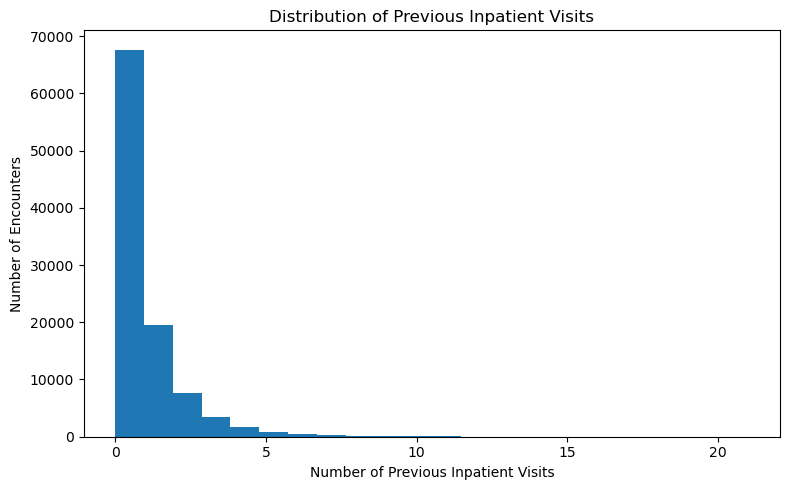

In [149]:
df_working["number_inpatient"].plot(
    kind="hist",
    bins=22,
    figsize=(8, 5)
)

plt.title("Distribution of Previous Inpatient Visits")
plt.xlabel("Number of Previous Inpatient Visits")
plt.ylabel("Number of Encounters")
plt.tight_layout()
plt.show()

### Business insights
From the distribution, we can see that most encounters have a low number of previous inpatient visits, with many patients having zero prior inpatient visits.

However, a smaller group has multiple previous inpatient encounters. This group represents patients with higher historical healthcare utilization, making prior inpatient utilization an important candidate variable for the later readmission-risk model.


#### Previous Emergency Visits — number_emergency
The care-management team also wants to understand patients' previous emergency-care utilization. Repeated emergency visits may indicate patients who have experienced recurring or urgent healthcare needs.

In [150]:
number_emergency_stats = df_working["number_emergency"].describe()

number_emergency_stats

count    101766.000000
mean          0.197836
std           0.930472
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          76.000000
Name: number_emergency, dtype: float64

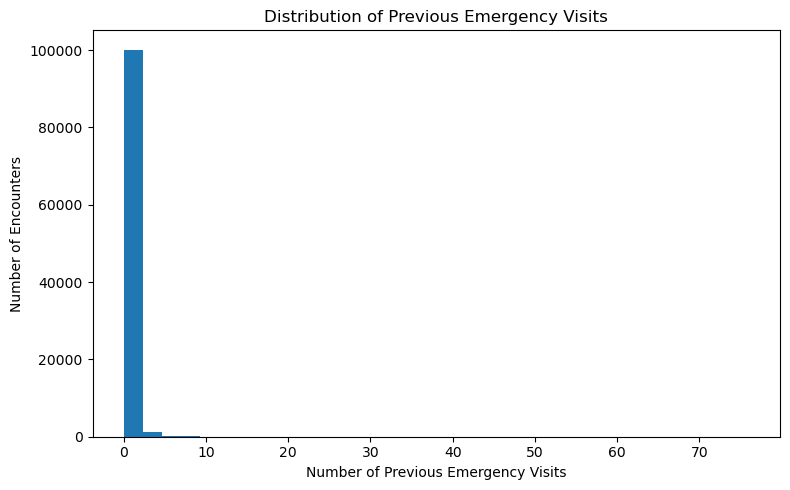

In [151]:
df_working["number_emergency"].plot(
    kind="hist",
    bins=33,
    figsize=(8, 5)
)

plt.title("Distribution of Previous Emergency Visits")
plt.xlabel("Number of Previous Emergency Visits")
plt.ylabel("Number of Encounters")
plt.tight_layout()
plt.show()

### Business Insight
The distribution is concentrated toward lower numbers of previous emergency visits, while a smaller proportion of encounters have multiple previous emergency visits.

This indicates that previous emergency utilization varies considerably across patients and may help identify patients with higher historical healthcare utilization.

##### Hospital Length of Stay — time_in_hospital

The hospital needs to understand how long patients typically remain hospitalized. Length of stay reflects the amount of inpatient care and resources associated with an encounter.

In [152]:
time_in_hospital_stats = df_working["time_in_hospital"].describe()

time_in_hospital_stats

count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64

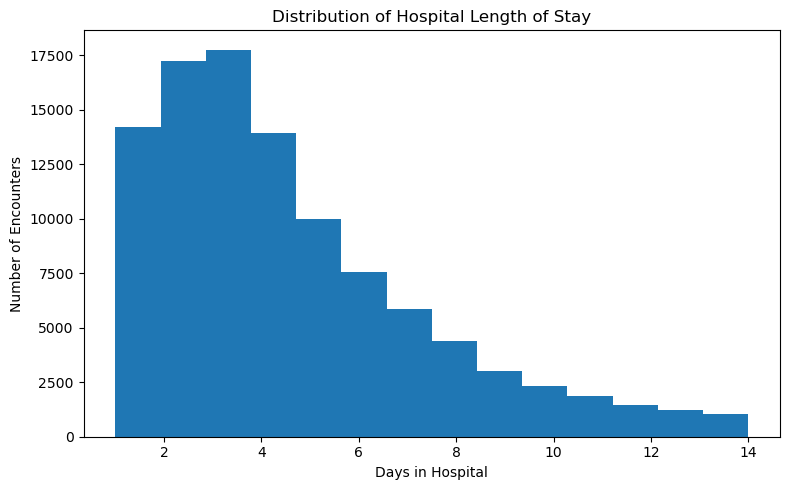

In [153]:
df_working["time_in_hospital"].plot(
    kind="hist",
    bins=14,
    figsize=(8, 5)
)

plt.title("Distribution of Hospital Length of Stay")
plt.xlabel("Days in Hospital")
plt.ylabel("Number of Encounters")
plt.tight_layout()
plt.show()

#### Business Insight

Hospital stays range from 1 to 14 days, with encounters concentrated around shorter and moderate lengths of stay.

This provides the hospital with an understanding of inpatient resource utilization and gives us a candidate variable to investigate against 30-day readmission.

### Number of Medications — num_medications
The care-management team wants to understand the medication burden of hospitalized patients. A higher number of medications can indicate a more complex treatment profile and therefore deserves investigation in the readmission problem.

In [154]:
num_medications_stats = df_working["num_medications"].describe()

num_medications_stats

count    101766.000000
mean         16.021844
std           8.127566
min           1.000000
25%          10.000000
50%          15.000000
75%          20.000000
max          81.000000
Name: num_medications, dtype: float64

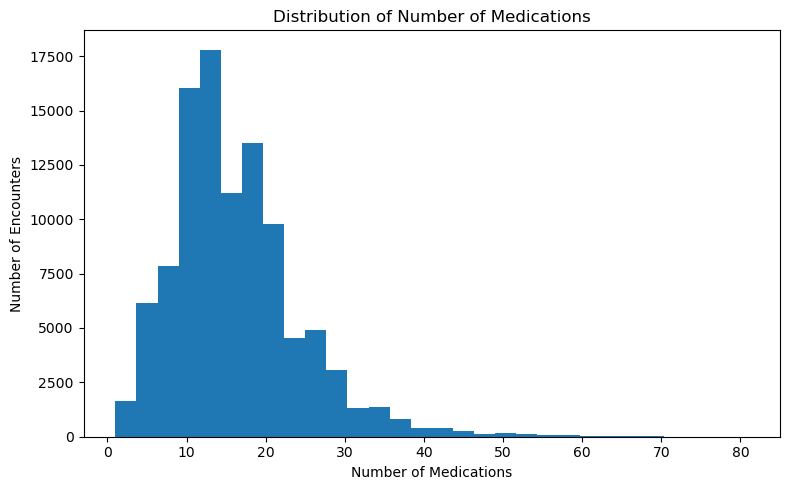

In [155]:
df_working["num_medications"].plot(
    kind="hist",
    bins=30,
    figsize=(8, 5)
)

plt.title("Distribution of Number of Medications")
plt.xlabel("Number of Medications")
plt.ylabel("Number of Encounters")
plt.tight_layout()
plt.show()

Business Insight

The number of medications varies substantially across encounters, with most encounters having a moderate medication count and a smaller group having a substantially higher medication burden.

This indicates variation in treatment complexity across the hospitalized population.

#### Number of Diagnoses — number_diagnoses
The hospital wants to understand the clinical complexity of the patient population. The number of diagnoses recorded during an encounter provides an initial measure of how many conditions are documented for the patient.

In [156]:
number_diagnoses_stats = df_working["number_diagnoses"].describe()

number_diagnoses_stats

count    101766.000000
mean          7.422607
std           1.933600
min           1.000000
25%           6.000000
50%           8.000000
75%           9.000000
max          16.000000
Name: number_diagnoses, dtype: float64

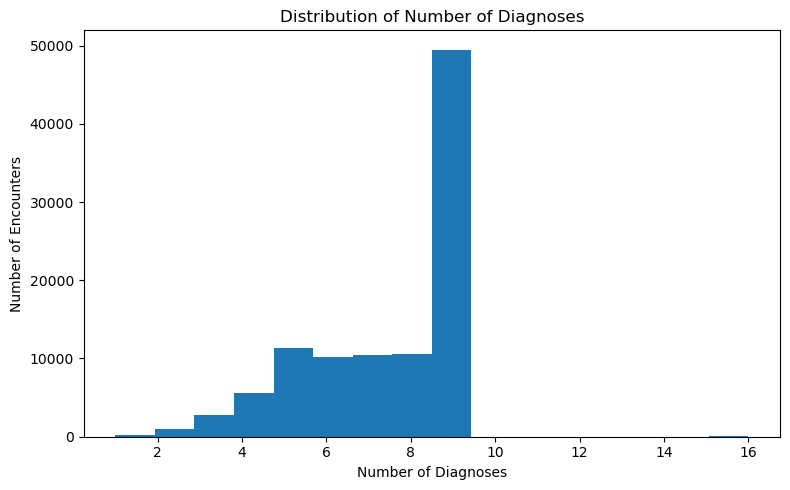

In [157]:
df_working["number_diagnoses"].plot(
    kind="hist",
    bins=16,
    figsize=(8, 5)
)

plt.title("Distribution of Number of Diagnoses")
plt.xlabel("Number of Diagnoses")
plt.ylabel("Number of Encounters")
plt.tight_layout()
plt.show()

### Business Insight

The dataset contains between 1 and 16 recorded diagnoses per encounter, with most encounters having a moderate number of diagnoses.

This suggests variation in clinical complexity among hospitalized patients and makes diagnosis burden a useful candidate variable for further readmission analysis.

In [158]:
### num_lab_procedures
num_lab_procedures_stats = df_working["num_lab_procedures"].describe()

num_lab_procedures_stats

count    101766.000000
mean         43.095641
std          19.674362
min           1.000000
25%          31.000000
50%          44.000000
75%          57.000000
max         132.000000
Name: num_lab_procedures, dtype: float64

In [159]:
# num_procedures
num_procedures_stats = df_working["num_procedures"].describe()

num_procedures_stats

count    101766.000000
mean          1.339730
std           1.705807
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max           6.000000
Name: num_procedures, dtype: float64

In [160]:
## number_outpatient
number_outpatient_stats = df_working["number_outpatient"].describe()

number_outpatient_stats

count    101766.000000
mean          0.369357
std           1.267265
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          42.000000
Name: number_outpatient, dtype: float64

### Categorical Univariate EDA
For categorical variables, we use value_counts() to understand the frequency and distribution of each category. This helps us identify dominant categories, rare categories, missing/unavailable values, and potentially important variables for the hospital readmission problem.

In [161]:
### age
age_distribution = (
    df_working["age"]
    .value_counts()
    .sort_index()
    .rename_axis("age_group")
    .reset_index(name="record_count")
)

age_distribution

,age_group,record_count
0,[0-10),161
1,[10-20),691
2,[20-30),1657
3,[30-40),3775
4,[40-50),9685
5,[50-60),17256
6,[60-70),22483
7,[70-80),26068
8,[80-90),17197
9,[90-100),2793


In [162]:
age_distribution["percentage"] = (
    age_distribution["record_count"]
    / len(df_working)
    * 100
)

age_distribution

,age_group,record_count,percentage
0,[0-10),161,0.158206
1,[10-20),691,0.679009
2,[20-30),1657,1.628245
3,[30-40),3775,3.709490
4,[40-50),9685,9.516931
5,[50-60),17256,16.956547
6,[60-70),22483,22.092840
7,[70-80),26068,25.615628
8,[80-90),17197,16.898571
9,[90-100),2793,2.744532


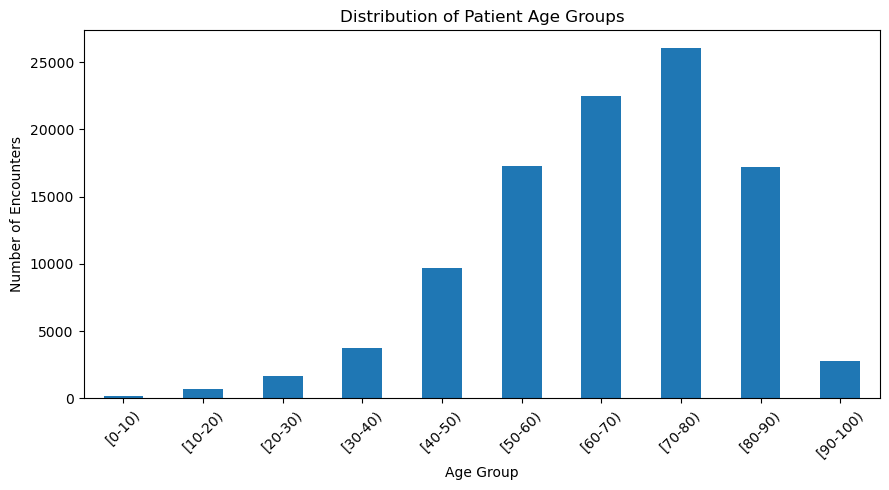

In [163]:
age_distribution.plot(
    x="age_group",
    y="record_count",
    kind="bar",
    figsize=(9, 5),
    legend=False
)

plt.title("Distribution of Patient Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Encounters")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### business insights
From the value counts and graph, we can identify which age groups represent the largest portion of hospital encounters and which groups are less represented.
This gives the hospital a baseline understanding of the patient population by age. Age is also a strong candidate for further investigation because the objective of the project is to identify patients at elevated risk of 30-day readmission.

In [ ]:
### admission_type_id

In [164]:
df_working["admission_type_id"].value_counts()

admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64

In [165]:
sorted(df_working["admission_type_id"].unique())

[np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8)]

In [166]:
admission_type_mapping

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,None
6,7,Trauma Center
7,8,Not Mapped


In [167]:
admission_type_distribution = (
    df_working["admission_type_id"]
    .value_counts()
    .sort_index()
    .rename_axis("admission_type_id")
    .reset_index(name="record_count")
)

admission_type_distribution

,admission_type_id,record_count
0,1,53990
1,2,18480
2,3,18869
3,4,10
4,5,4785
5,6,5291
6,7,21
7,8,320


In [168]:
admission_type_mapping["admission_type_id"] = pd.to_numeric(
    admission_type_mapping["admission_type_id"],
    errors="coerce"
).astype("Int64")

In [169]:
admission_type_distribution = admission_type_distribution.merge(
    admission_type_mapping,
    on="admission_type_id",
    how="left"
)

admission_type_distribution

,admission_type_id,record_count,description
0,1,53990,Emergency
1,2,18480,Urgent
2,3,18869,Elective
3,4,10,Newborn
4,5,4785,Not Available
5,6,5291,None
6,7,21,Trauma Center
7,8,320,Not Mapped


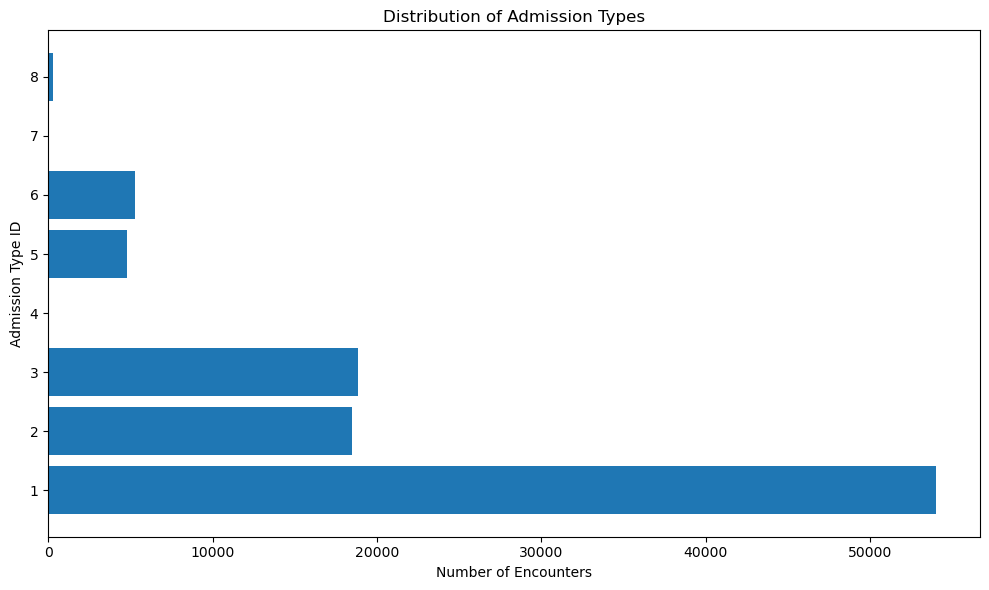

In [170]:
plt.figure(figsize=(10, 6))

plt.barh(
    admission_type_distribution["admission_type_id"].astype(str),
    admission_type_distribution["record_count"]
)

plt.title("Distribution of Admission Types")
plt.xlabel("Number of Encounters")
plt.ylabel("Admission Type ID")

plt.tight_layout()
plt.show()

### Business Insights — Admission Type

1.Hospital encounters are concentrated in a few admission types.
Some admission type IDs have much higher encounter volumes than others, showing that patient intake is not evenly distributed across admission pathways.

2.High-volume admission types are important for hospital operations.
These categories represent the largest patient-flow segments, so they can have a greater impact on bed allocation, staffing, clinical workload, and care coordination

3.Low-volume admission types represent smaller patient segments.
Their lower frequency does not mean they are invalid or unimportant. They may represent legitimate but less frequent admission pathways.

4.Admission type can be useful for our ML model.
It captures the context in which a patient enters the hospital, so it can be considered as a candidate feature for predicting 30-day readmission.

In [171]:
### medical_specialty.
df_working["medical_specialty"].value_counts()

medical_specialty
?                                49949
InternalMedicine                 14635
Emergency/Trauma                  7565
Family/GeneralPractice            7440
Cardiology                        5352
                                 ...  
SportsMedicine                       1
Speech                               1
Perinatology                         1
Neurophysiology                      1
Pediatrics-InfectiousDiseases        1
Name: count, Length: 73, dtype: int64

In [172]:
df_working["medical_specialty"].value_counts(dropna=False).head(20)

medical_specialty
?                                    49949
InternalMedicine                     14635
Emergency/Trauma                      7565
Family/GeneralPractice                7440
Cardiology                            5352
Surgery-General                       3099
Nephrology                            1613
Orthopedics                           1400
Orthopedics-Reconstructive            1233
Radiologist                           1140
Pulmonology                            871
Psychiatry                             854
Urology                                685
ObstetricsandGynecology                671
Surgery-Cardiovascular/Thoracic        652
Gastroenterology                       564
Surgery-Vascular                       533
Surgery-Neuro                          468
PhysicalMedicineandRehabilitation      391
Oncology                               348
Name: count, dtype: int64

In [173]:
medical_specialty_distribution = (
    df_working["medical_specialty"]
    .value_counts()
    .head(15)
    .rename_axis("medical_specialty")
    .reset_index(name="record_count")
)

medical_specialty_distribution

,medical_specialty,record_count
0,?,49949
1,InternalMedicine,14635
2,Emergency/Trauma,7565
3,Family/GeneralPractice,7440
4,Cardiology,5352
5,Surgery-General,3099
6,Nephrology,1613
7,Orthopedics,1400
8,Orthopedics-Reconstructive,1233
9,Radiologist,1140


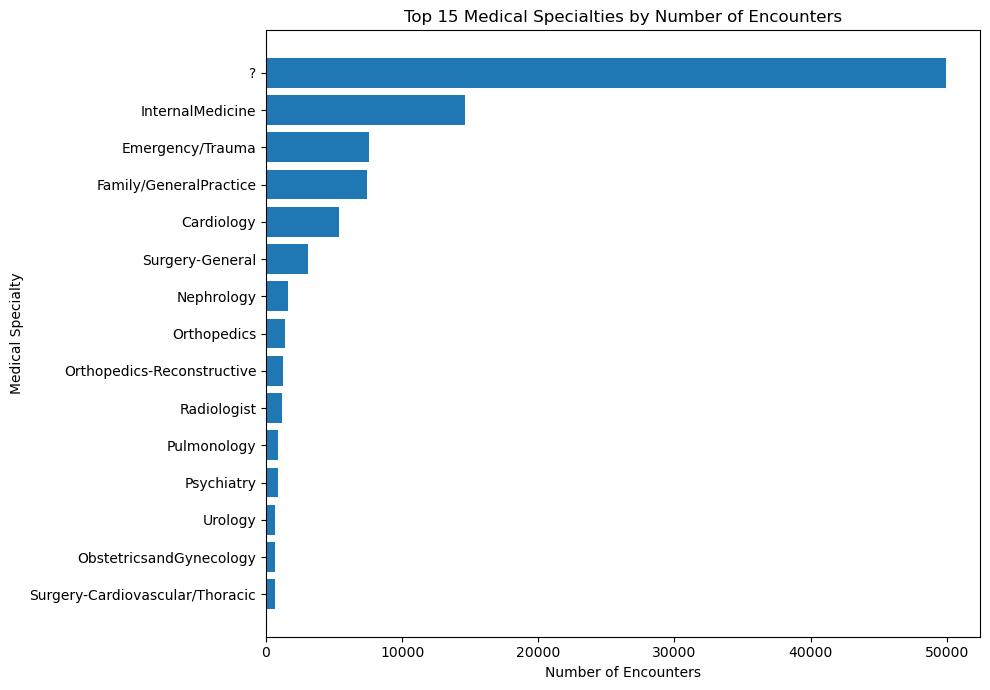

In [174]:
plt.figure(figsize=(10, 7))

plt.barh(
    medical_specialty_distribution["medical_specialty"][::-1],
    medical_specialty_distribution["record_count"][::-1]
)

plt.title("Top 15 Medical Specialties by Number of Encounters")
plt.xlabel("Number of Encounters")
plt.ylabel("Medical Specialty")

plt.tight_layout()
plt.show()

In [175]:
##max_glu_serum
df_working["max_glu_serum"].value_counts(dropna=False)

max_glu_serum
None    96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64

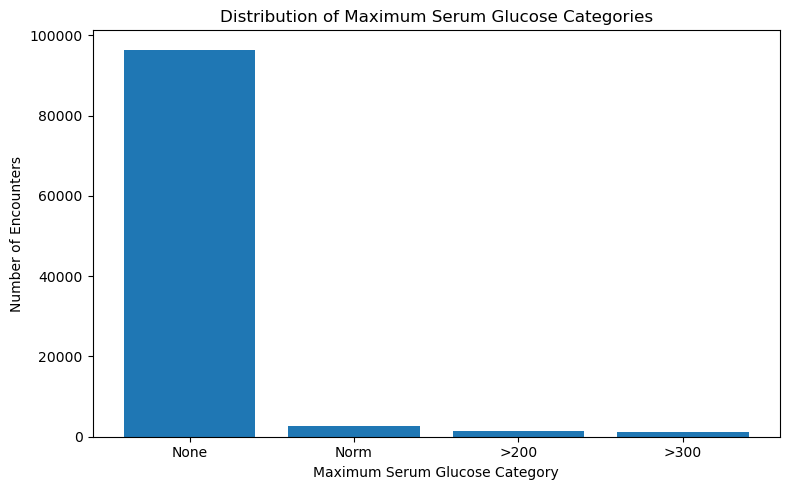

In [176]:
max_glu_distribution = (
    df_working["max_glu_serum"]
    .value_counts(dropna=False)
    .rename_axis("max_glu_serum")
    .reset_index(name="record_count")
)

plt.figure(figsize=(8, 5))

plt.bar(
    max_glu_distribution["max_glu_serum"].astype(str),
    max_glu_distribution["record_count"]
)

plt.title("Distribution of Maximum Serum Glucose Categories")
plt.xlabel("Maximum Serum Glucose Category")
plt.ylabel("Number of Encounters")

plt.tight_layout()
plt.show()

### Business Insights — Maximum Serum Glucose

From your actual graph:

1. The majority of encounters have None for maximum serum glucose.
This means maximum glucose information was not recorded/not available for most encounters. This is a major data-availability finding.
2. Only a small proportion of encounters have a recorded glucose category.
Among the recorded values, encounters are divided into Normal, >200, and >300 glucose categories.
3. The >300 category represents very high glucose levels.
Although it has relatively few encounters compared with the None group, it represents a clinically important subgroup that may require closer attention.
4. The large amount of missing information is important for our ML project.
We should not remove these records simply because glucose is not recorded. During feature engineering, we can represent the absence of a glucose measurement explicitly.
5 .max_glu_serum is a potentially useful ML feature, because the recorded glucose category can provide information about the patient's clinical condition. However, its predictive value must be confirmed through bivariate analysis with 30-day readmission.

In [177]:
## A1Cresult
df_working["A1Cresult"].value_counts(dropna=False)

A1Cresult
None    84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64

In [178]:
A1C_distribution = (
    df_working["A1Cresult"]
    .value_counts(dropna=False)
    .rename_axis("A1Cresult")
    .reset_index(name="record_count")
)

A1C_distribution

,A1Cresult,record_count
0,None,84748
1,>8,8216
2,Norm,4990
3,>7,3812


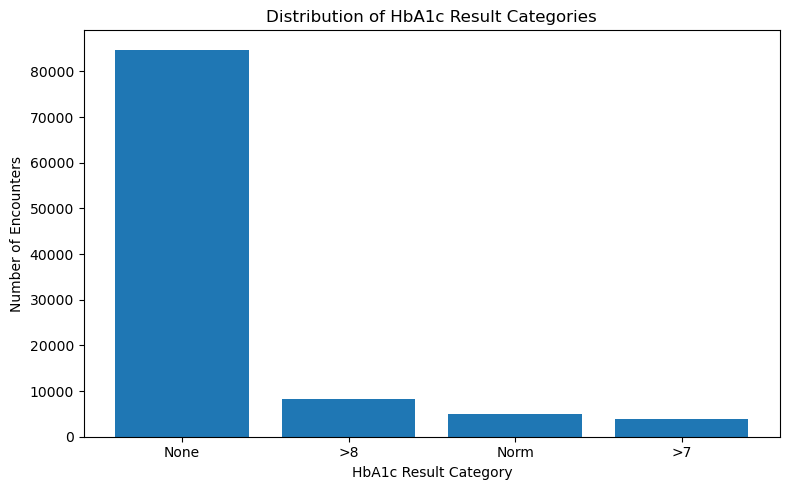

In [179]:
plt.figure(figsize=(8, 5))

plt.bar(
    A1C_distribution["A1Cresult"].astype(str),
    A1C_distribution["record_count"]
)

plt.title("Distribution of HbA1c Result Categories")
plt.xlabel("HbA1c Result Category")
plt.ylabel("Number of Encounters")

plt.tight_layout()
plt.show()

### Business Insights — A1C Result

From your actual graph:

1. Most encounters have None for A1Cresult.
This shows that HbA1c testing/result information is not recorded for a large majority of encounters.
2. Among the recorded results, >8 is the largest category.
This indicates that, within the encounters where A1C was recorded, a substantial group had an HbA1c result above 8.
3. Norm and >7 represent smaller groups compared with the >8 category.
4. The large None category is an important data-quality finding.
We should not delete these encounters or use fillna() during EDA. The absence of a recorded A1C result will be addressed during feature engineering.
5. A1Cresult is a relevant candidate ML feature.
It provides information about glucose-control status and may help the readmission model, but its actual relationship with 30-day readmission must be tested during bivariate analysis.

### insulin
insulin is worth analyzing because it represents the insulin treatment status during the encounter and may provide useful information about the patient's treatment intensity.

In [180]:
df_working["insulin"].value_counts()

insulin
No        47383
Steady    30849
Down      12218
Up        11316
Name: count, dtype: int64

In [181]:
insulin_distribution = (
    df_working["insulin"]
    .value_counts()
    .rename_axis("insulin")
    .reset_index(name="record_count")
)

insulin_distribution

,insulin,record_count
0,No,47383
1,Steady,30849
2,Down,12218
3,Up,11316


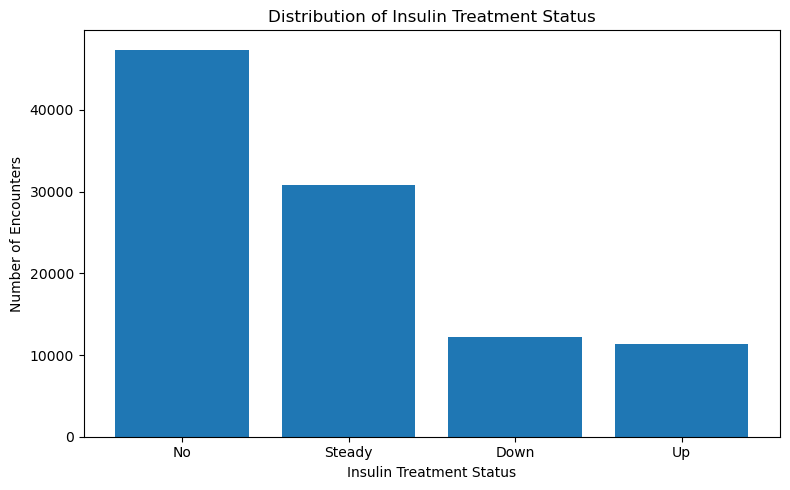

In [182]:
plt.figure(figsize=(8, 5))

plt.bar(
    insulin_distribution["insulin"],
    insulin_distribution["record_count"]
)

plt.title("Distribution of Insulin Treatment Status")
plt.xlabel("Insulin Treatment Status")
plt.ylabel("Number of Encounters")

plt.tight_layout()
plt.show()

### Business Insights — Insulin Treatment Status

From your actual graph:

1. No is the largest category, meaning the largest group of encounters did not have insulin treatment recorded during the encounter.
2. Steady is the second-largest category, showing that a substantial number of encounters involved patients whose insulin treatment remained at a steady level.
3. Down and Up have lower encounter volumes compared with No and Steady, representing smaller groups where insulin treatment was decreased or increased.
4. The distribution shows different levels of insulin-treatment intensity/change across patients. This can help the hospital understand the treatment patterns within its diabetic patient population.
5. insulin is a useful candidate feature for our ML model because treatment status can provide context about the patient's clinical management during the hospitalization.

### diabetesMed
diabetesMed tells us whether the patient was receiving diabetes medication during the encounter. It is useful for understanding the overall treatment status of the diabetic patient population.

In [ ]:
df_working["diabetesMed"].value_counts()

In [183]:
diabetes_med_distribution = (
    df_working["diabetesMed"]
    .value_counts()
    .rename_axis("diabetesMed")
    .reset_index(name="record_count")
)

diabetes_med_distribution

,diabetesMed,record_count
0,Yes,78363
1,No,23403


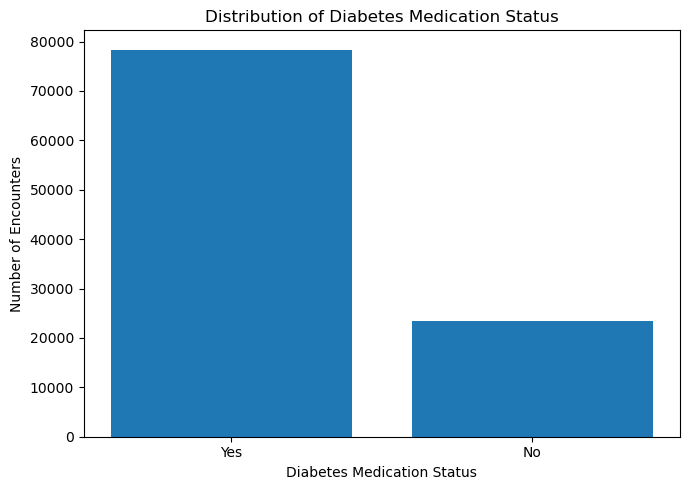

In [184]:
plt.figure(figsize=(7, 5))

plt.bar(
    diabetes_med_distribution["diabetesMed"],
    diabetes_med_distribution["record_count"]
)

plt.title("Distribution of Diabetes Medication Status")
plt.xlabel("Diabetes Medication Status")
plt.ylabel("Number of Encounters")

plt.tight_layout()
plt.show()

#### Business Insights — Diabetes Medication Status

1. Most encounters are for patients receiving diabetes medication.
The Yes category is much larger than No, showing that diabetes medication was recorded for the majority of hospital encounters.
2. A smaller group did not receive diabetes medication.
The No category represents a substantial but clearly smaller portion of encounters.
3. The hospital population is therefore predominantly under diabetes medication management.
This is useful for understanding the treatment profile of the patients represented in the dataset.
4. diabetesMed is a relevant candidate feature for our ML model.
Medication status provides information about the patient's treatment context and may contribute to identifying patients who need closer follow-up.

### Bivariate Analysis — Readmission Risk & Business Relationships

Previous Inpatient Visits vs Emergency Visits

#### Case scenario

The hospital wants to understand whether patients who have more previous inpatient encounters also tend to have more emergency visits. This can reveal patterns of repeated healthcare utilization.

## Objective

Examine the relationship between previous inpatient utilization and emergency utilization.

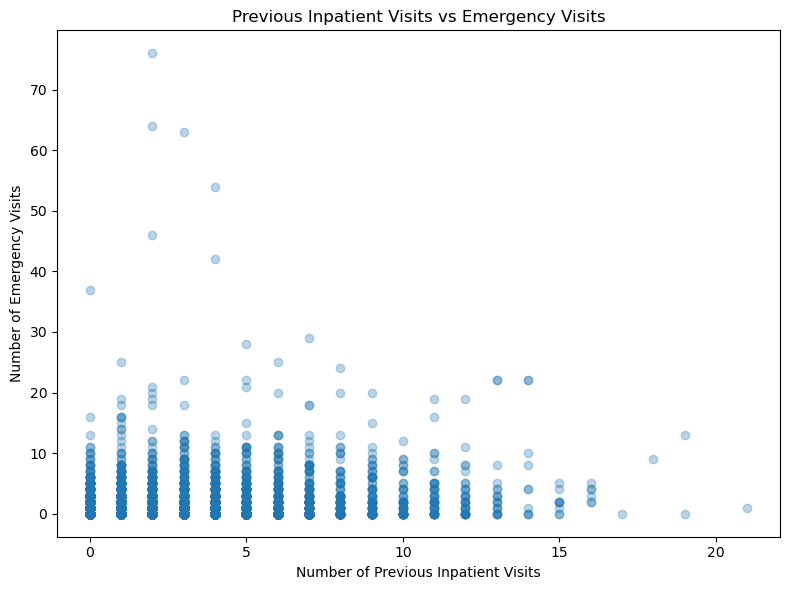

In [185]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_working["number_inpatient"],
    df_working["number_emergency"],
    alpha=0.3
)

plt.title("Previous Inpatient Visits vs Emergency Visits")
plt.xlabel("Number of Previous Inpatient Visits")
plt.ylabel("Number of Emergency Visits")

plt.tight_layout()
plt.show()

#### Business Insights — Previous Inpatient Visits vs Emergency Visit

1. Most encounters are concentrated at low numbers of previous inpatient visits and low emergency visits. This indicates that the majority of patients have relatively limited prior hospital utilization.
2. Patients with more previous inpatient visits can also have higher emergency utilization, but the points are widely scattered. So the relationship is not strongly linear.
3. There are a few encounters with unusually high emergency visits, especially at lower inpatient-visit levels. These represent patients with intensive emergency-care utilization and should be investigated as a potentially important patient segment.
4. The plot suggests that inpatient and emergency utilization capture different aspects of healthcare usage. A patient can have many emergency visits without having many previous inpatient admissions.


### Previous Inpatient Visits vs Number of Diagnoses

### Case scenario

The hospital wants to understand whether patients with more previous inpatient visits also tend to have a higher number of diagnoses recorded during the encounter.

## Business objective

Identify whether repeated hospital utilization is associated with greater clinical complexity.

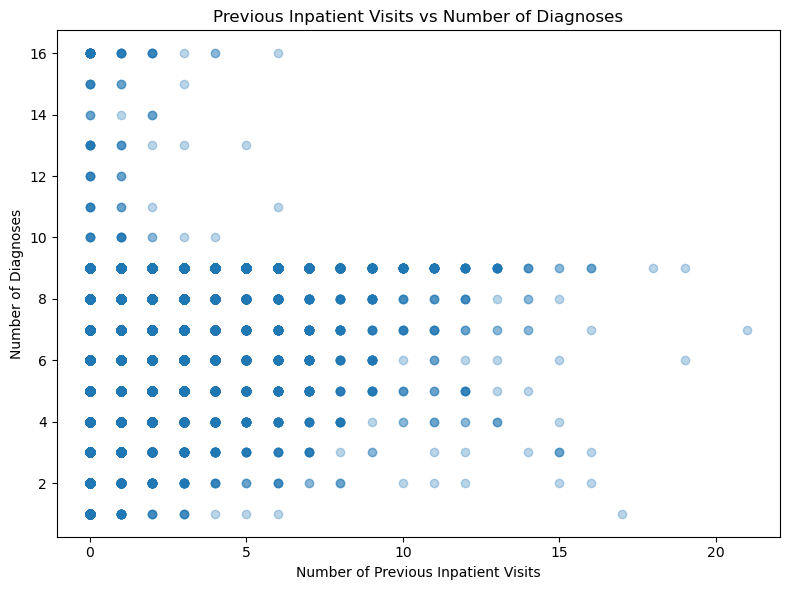

In [186]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_working["number_inpatient"],
    df_working["number_diagnoses"],
    alpha=0.3
)

plt.title("Previous Inpatient Visits vs Number of Diagnoses")
plt.xlabel("Number of Previous Inpatient Visits")
plt.ylabel("Number of Diagnoses")

plt.tight_layout()
plt.show()

### Business Insights — Previous Inpatient Visits vs Number of Diagnoses

1. Most encounters are concentrated around a moderate number of diagnoses (roughly 5–9), while very low and very high diagnosis counts are less common.
2. Patients with many previous inpatient visits are not consistently associated with a higher number of diagnoses. The points remain widely distributed, so there is no strong linear relationship between these two variables.
3. High clinical complexity can occur even among patients with few previous inpatient visits. The graph shows encounters with a high number of diagnoses even when previous inpatient visits are close to zero.
4. Repeated inpatient utilization and number of diagnoses provide different information. Therefore, both variables can be useful independently when describing patient risk and healthcare utilization.

In [ ]:
#### Length of Stay vs Medication Burden


### Case scenario

The hospital wants to understand whether longer hospital stays are associated with a higher number of medications. This can help identify treatment complexity and support resource and discharge planning.

### Business objective

Examine whether patients with longer hospital stays tend to have a greater medication burden.

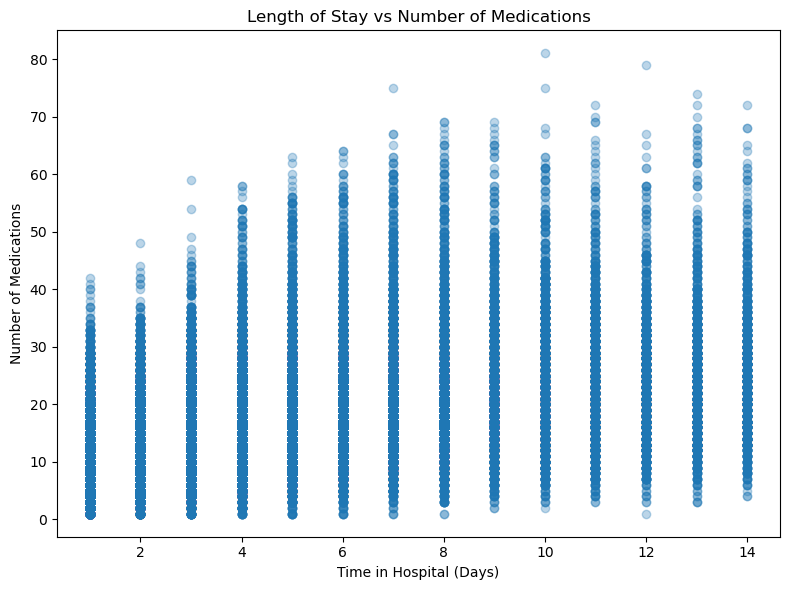

In [187]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_working["time_in_hospital"],
    df_working["num_medications"],
    alpha=0.3
)

plt.title("Length of Stay vs Number of Medications")
plt.xlabel("Time in Hospital (Days)")
plt.ylabel("Number of Medications")

plt.tight_layout()
plt.show()

#### Business Insights — Length of Stay vs Number of Medications

1. Medication count generally increases as length of hospital stay increases.
Encounters with longer stays show a wider and generally higher range of medication counts.
2. Short stays tend to have lower medication burden.
Patients staying around 1–3 days are mostly concentrated at lower medication counts.
3. Longer stays show greater treatment complexity.
From around 6–14 days, the spread of medication counts becomes much wider, including encounters with substantially higher medication use.
4. The relationship is positive but not perfectly linear.
Patients with the same length of stay can have very different medication counts, so length of stay alone does not determine medication burden.

In [ ]:
#### Number of Medications vs Number of Diagnoses

### Case scenario

The hospital wants to understand whether patients with a higher number of diagnoses also tend to require more medications during their hospital encounter.

## Business objective

Examine the relationship between clinical complexity and medication burden to understand treatment-resource requirements.

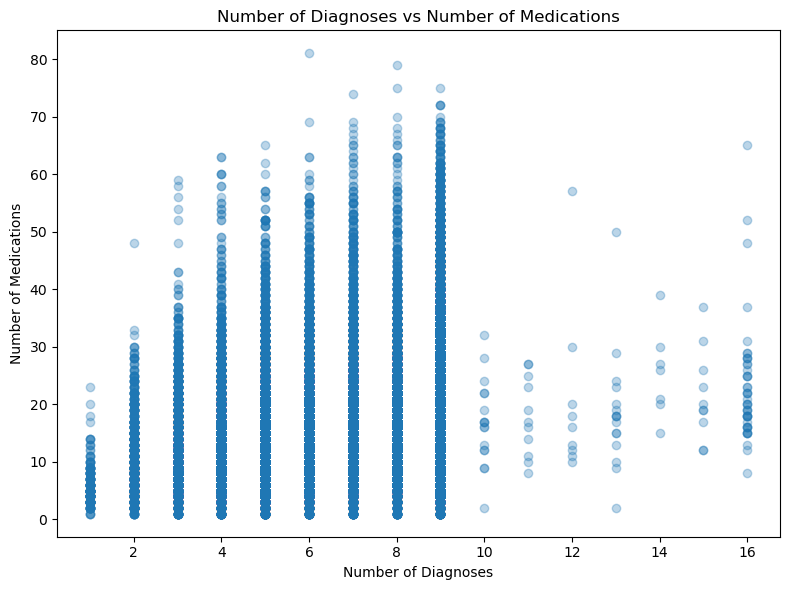

In [188]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_working["number_diagnoses"],
    df_working["num_medications"],
    alpha=0.3
)

plt.title("Number of Diagnoses vs Number of Medications")
plt.xlabel("Number of Diagnoses")
plt.ylabel("Number of Medications")

plt.tight_layout()
plt.show()

#### Business Insights — Number of Diagnoses vs Number of Medications

1. There is a clear positive relationship between number of diagnoses and number of medications. As the number of diagnoses increases from the lower levels toward about 9 diagnoses, the distribution generally shifts toward higher medication counts.
2. Patients with fewer diagnoses generally have lower medication burden. The points for 1–3 diagnoses are concentrated mostly at lower medication counts.
3. Higher diagnosis counts show greater medication burden and wider variation. Particularly around 6–9 diagnoses, there are many encounters with substantially higher numbers of medications.
4. The relationship is not perfectly linear. Patients with the same number of diagnoses can have very different medication counts, meaning diagnosis burden alone does not determine treatment intensity.
5. Business implication: Patients with greater clinical complexity may require more medication-management effort. This can support pharmacy coordination, medication reconciliation, discharge planning, and care-management prioritization.

### Categorical vs Categorical.

### Maximum Glucose vs A1C Result


## Case scenario

The hospital wants to understand how maximum serum glucose results are distributed across different A1C result categories. This can help identify whether different glucose-control indicators tend to appear together.

## Business objective

Examine the relationship between maximum serum glucose category and A1C result category.

In [189]:
glucose_a1c_crosstab = pd.crosstab(
    df_working["max_glu_serum"],
    df_working["A1Cresult"]
)

glucose_a1c_crosstab

A1Cresult,>7,>8,None,Norm
max_glu_serum,,,,
>200,18,36,1414,17
>300,15,112,1135,2
None,3749,8039,79700,4932
Norm,30,29,2499,39


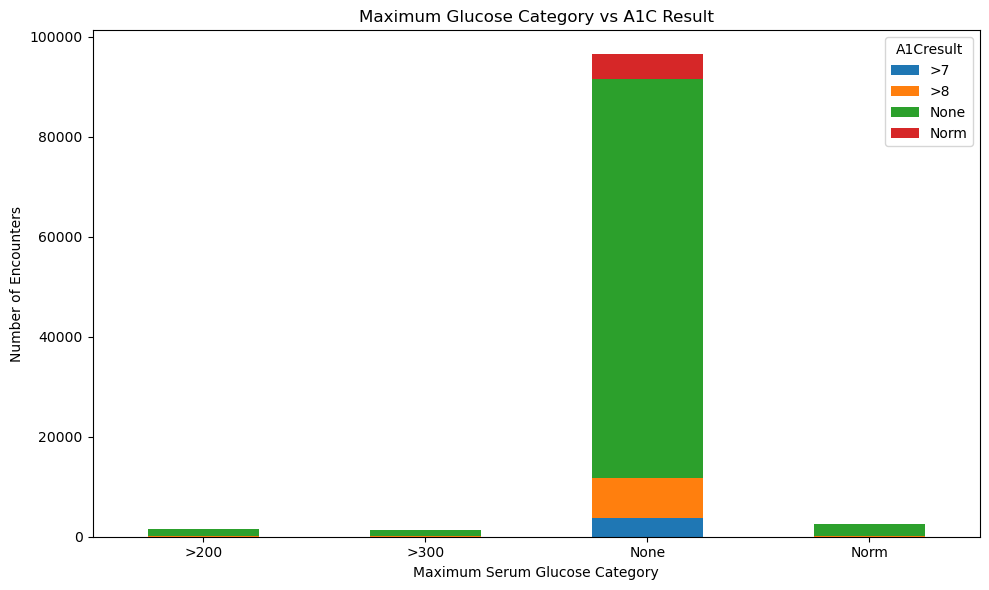

In [190]:
glucose_a1c_crosstab.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Maximum Glucose Category vs A1C Result")
plt.xlabel("Maximum Serum Glucose Category")
plt.ylabel("Number of Encounters")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Business Insights — Maximum Glucose Category vs A1C Result

1. Most encounters have both glucose and A1C information unrecorded (None).
The very large None portion shows that laboratory-result information is missing/not documented for a substantial share of encounters.
2. Among encounters with recorded maximum glucose results, the >200 and >300 groups are relatively small.
These represent smaller patient segments with elevated or very high recorded glucose levels.
3. The None category dominates across the combinations, so we should be careful about drawing strong clinical conclusions from this relationship without considering the missing-data pattern.
4. The two glucose indicators provide complementary information.
Maximum serum glucose represents an encounter-level glucose measurement category, while A1C provides information about longer-term glucose control. Examining both together can therefore help characterize the patient's clinical profile.

### Insulin Treatment vs Diabetes Medication
## Case scenario

The hospital wants to understand how insulin treatment status relates to the patient's overall diabetes medication status during the encounter.

## Business objective

Identify treatment patterns that can help the hospital understand diabetes-management intensity across its patient population.

In [191]:
insulin_med_crosstab = pd.crosstab(
    df_working["insulin"],
    df_working["diabetesMed"]
)

insulin_med_crosstab

diabetesMed,No,Yes
insulin,,
Down,0,12218
No,23403,23980
Steady,0,30849
Up,0,11316


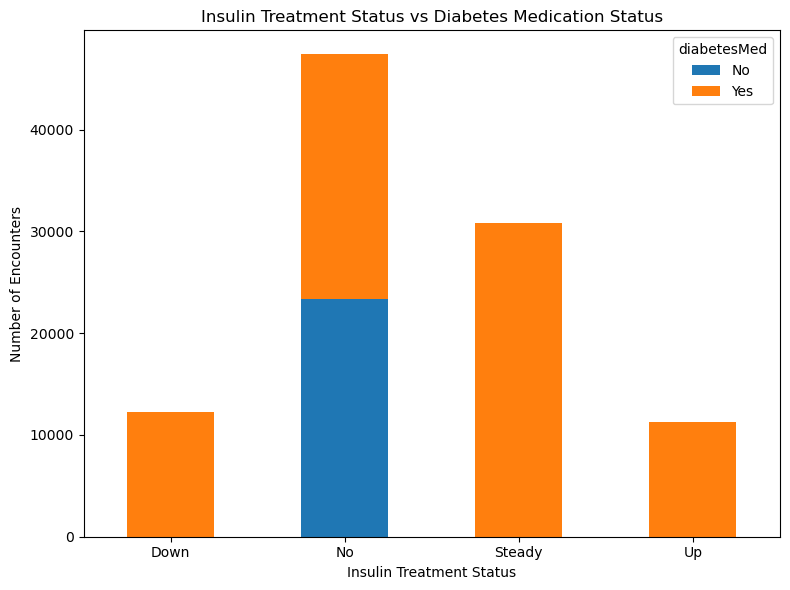

In [192]:
insulin_med_crosstab.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 6)
)

plt.title("Insulin Treatment Status vs Diabetes Medication Status")
plt.xlabel("Insulin Treatment Status")
plt.ylabel("Number of Encounters")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Business Insights — Insulin Treatment vs Diabetes Medication

1. Most encounters in every insulin category have diabetesMed = Yes.
This shows that diabetes medication management is common across the different insulin treatment statuses.
2. The No insulin group has the largest overall number of encounters.
However, even within this group, a substantial number of encounters have diabetesMed = Yes, meaning not receiving insulin does not mean the patient was not receiving diabetes medication.
3. The Steady insulin group is the second-largest group and is almost entirely associated with diabetesMed = Yes.
This indicates that patients with steady insulin treatment are generally part of the broader diabetes-medication management population.
4. The Down and Up insulin groups are smaller but almost entirely diabetesMed = Yes.

### Admission Type vs Medical Specialty
## Case scenario

The hospital wants to understand whether different admission pathways are concentrated in particular medical specialties. This can help understand how patients enter the hospital and where clinical workload is concentrated.

## Business objective

Examine the relationship between admission type and medical specialty to understand hospital patient-flow patterns.

In [193]:
admission_specialty_crosstab = pd.crosstab(
    df_working["admission_type_id"],
    df_working["medical_specialty"]
)

admission_specialty_crosstab

medical_specialty,?,AllergyandImmunology,Anesthesiology,Anesthesiology-Pediatric,Cardiology,Cardiology-Pediatric,DCPTEAM,Dentistry,Dermatology,Emergency/Trauma,...,Surgery-General,Surgery-Maxillofacial,Surgery-Neuro,Surgery-Pediatric,Surgery-Plastic,Surgery-PlasticwithinHeadandNeck,Surgery-Thoracic,Surgery-Vascular,SurgicalSpecialty,Urology
admission_type_id,,,,,,,,,,,,,,,,,,,,,
1,33245,0,3,12,1629,0,2,1,0,2452,...,536,2,69,3,4,0,6,17,3,82
2,5485,1,3,4,1017,7,1,2,1,4199,...,903,8,92,2,8,0,6,103,10,122
3,6766,0,6,2,1730,0,3,0,0,890,...,1158,0,283,3,21,0,73,387,20,396
4,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,3028,0,0,0,156,0,0,0,0,1,...,216,0,0,0,1,0,0,0,0,44
6,1360,6,0,1,793,0,0,1,0,23,...,251,1,12,0,3,1,7,4,0,33
7,21,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,36,0,0,0,27,0,0,0,0,0,...,35,0,12,0,4,0,17,22,0,8


In [194]:
top_specialties = (
    df_working["medical_specialty"]
    .value_counts()
    .head(10)
    .index
)

admission_specialty_top = admission_specialty_crosstab[
    top_specialties
]

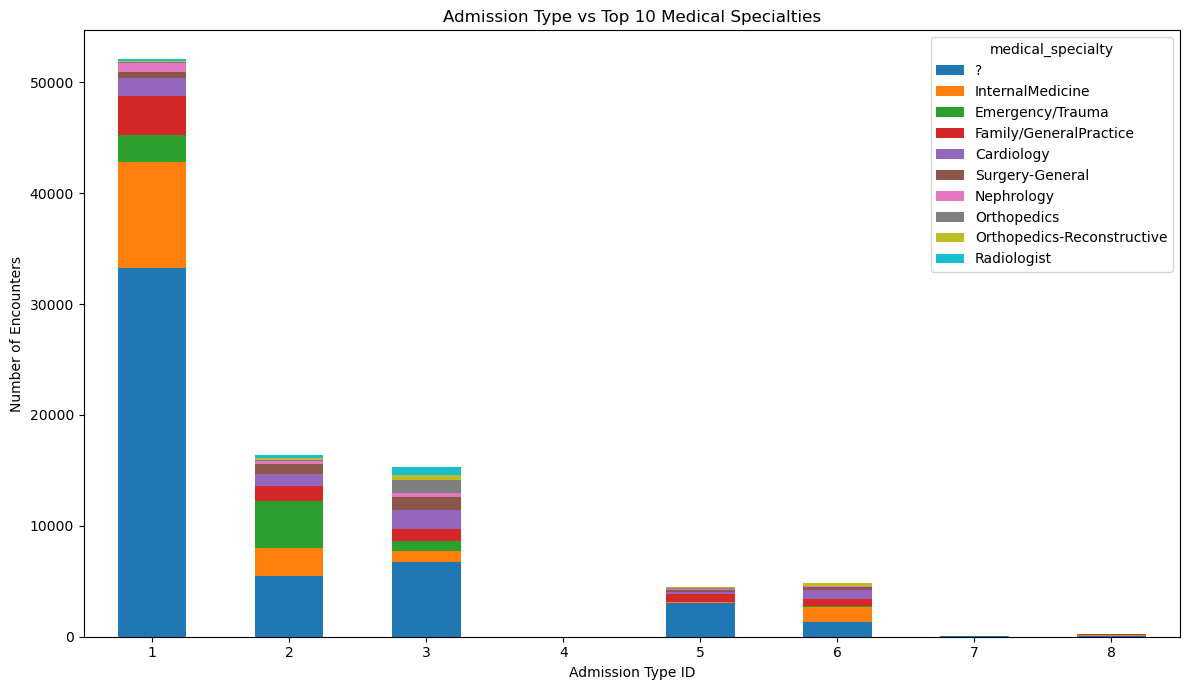

In [195]:
admission_specialty_top.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Admission Type vs Top 10 Medical Specialties")
plt.xlabel("Admission Type ID")
plt.ylabel("Number of Encounters")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Business Insights — Admission Type vs Medical Specialty

1.Admission Type 1 has the highest overall encounter volume by a large margin.
This indicates that this admission pathway is the dominant route through which patients enter the hospital.

2.The ? medical-specialty category forms a very large portion of encounters across the admission types.
This confirms the earlier finding that medical-specialty information is frequently unrecorded. It is an important data-quality issue, not an outlier.

3.Internal Medicine is a major identified specialty across several admission types, particularly in the higher-volume admission categories. This indicates that general medical care contributes substantially to hospital activity.
   
4.Emergency/Trauma and Family/General Practice also contribute noticeably to some admission types, showing that the clinical composition of encounters differs depending on the admission pathway.

5.Admission types 4, 7, and 8 have very small overall volumes compared with the major admission types. These should not automatically be treated as invalid; they are simply less frequent categories in this dataset.

6.Business implication: Understanding the combination of admission pathway and specialty can help hospitals plan staffing, bed capacity, clinical resources, and care-management workload according to how patients enter the hospital.

### Categorical vs Numerical

## age vs number_inpatient
### Case scenario

The hospital wants to understand whether prior inpatient utilization differs across age groups. This can help identify age segments that may require different levels of care coordination.

### Business objective

Compare previous inpatient utilization across patient age groups.

Because age is categorical and number_inpatient is numerical, a box plot is appropriate. It shows the distribution, median, spread, and unusually high utilization within each age group.

<Figure size 1000x600 with 0 Axes>

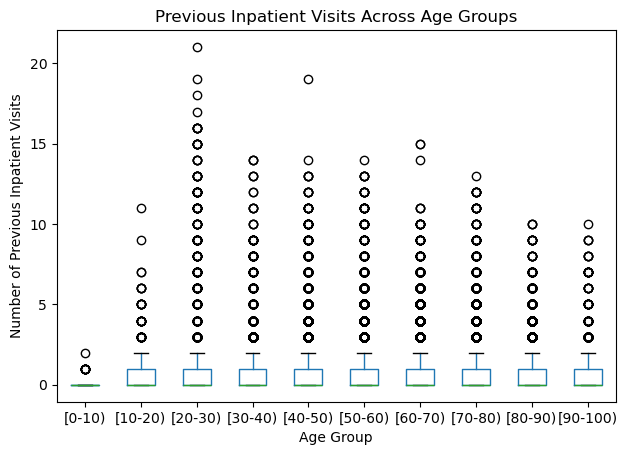

In [196]:
plt.figure(figsize=(10, 6))

df_working.boxplot(
    column="number_inpatient",
    by="age",
    grid=False
)

plt.title("Previous Inpatient Visits Across Age Groups")
plt.suptitle("")
plt.xlabel("Age Group")
plt.ylabel("Number of Previous Inpatient Visits")

plt.tight_layout()
plt.show()

### Business Insights — Age Group vs Previous Inpatient Visits

1. Most age groups have a median of approximately 0–1 previous inpatient visits. This shows that prior inpatient utilization is relatively low for the typical encounter across age groups.
   
2.The 20–30 age group shows a particularly wide range of high-utilization observations, with several encounters reaching more than 10 previous inpatient visits and the highest observed value in the plot.

3.Older age groups also contain high-utilization patients, especially the 60–70 and 70–80 groups, but their extreme values are generally lower than the highest observations seen in some younger groups.

4.There are many high-value observations outside the box in several age groups. These are observations identified as statistical outliers by the box-plot rule; we should not remove them automatically because repeated hospital utilization can be a genuine patient characteristic.

## Medical Specialty vs Length of Hospital Stay

In [ ]:
### Case scenario

The hospital wants to understand whether length of stay differs across medical specialties. This can help identify specialties associated with greater inpatient resource requirements.

## Business objective

Compare hospital stay duration across major medical specialties to identify differences in resource utilization.

<Figure size 1200x700 with 0 Axes>

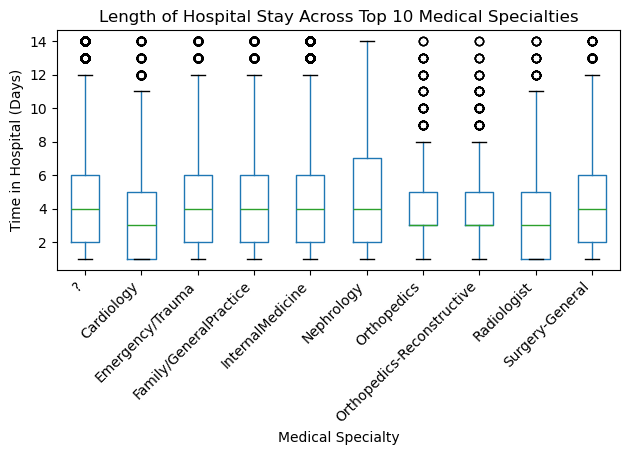

In [197]:
top_specialties = (
    df_working["medical_specialty"]
    .value_counts()
    .head(10)
    .index
)

specialty_stay_data = df_working[
    df_working["medical_specialty"].isin(top_specialties)
]

plt.figure(figsize=(12, 7))

specialty_stay_data.boxplot(
    column="time_in_hospital",
    by="medical_specialty",
    grid=False
)

plt.title("Length of Hospital Stay Across Top 10 Medical Specialties")
plt.suptitle("")
plt.xlabel("Medical Specialty")
plt.ylabel("Time in Hospital (Days)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Business Insights — Medical Specialty vs Length of Hospital Stay

1. Most specialties have a median hospital stay around 3–4 days. This indicates that typical length of stay is fairly similar across the major specialties.
2. Nephrology shows the widest distribution and the highest upper range, reaching up to about 14 days. This suggests greater variation in hospitalization duration within this specialty.
3. Cardiology, Family/General Practice, Internal Medicine, and Surgery-General also show substantial variation in length of stay, with encounters extending to longer stays.
4. Orthopedics and Orthopedics-Reconstructive have relatively concentrated distributions, although they still contain several high-length-of-stay observations.
5.High-value observations appear across almost every specialty. These are potential statistical outliers, but they should not be removed automatically because long hospital stays can be legitimate clinical cases.

In [ ]:
#### Insulin Treatment Status vs Number of Medications


### Case scenario

The hospital wants to understand whether insulin treatment status is associated with the number of medications used during the encounter. This helps us understand treatment burden across different insulin-management groups.

### Business objective

Compare medication burden across different insulin treatment statuses to identify differences in treatment complexity.

<Figure size 800x600 with 0 Axes>

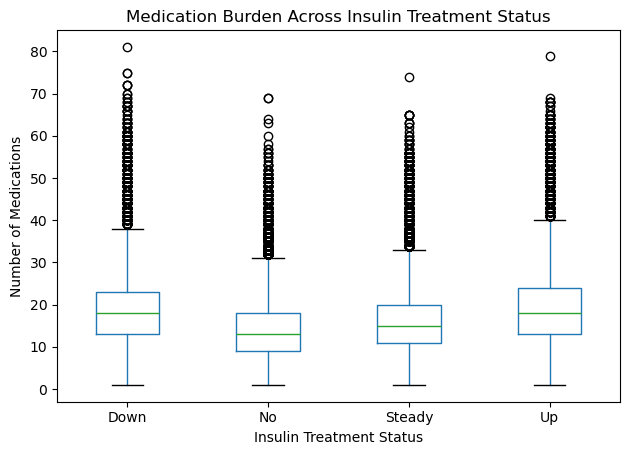

In [198]:
plt.figure(figsize=(8, 6))

df_working.boxplot(
    column="num_medications",
    by="insulin",
    grid=False
)

plt.title("Medication Burden Across Insulin Treatment Status")
plt.suptitle("")
plt.xlabel("Insulin Treatment Status")
plt.ylabel("Number of Medications")

plt.tight_layout()
plt.show()

### Business Insights — Insulin Treatment Status vs Number of Medications

1. The Up and Down insulin groups have the highest median medication burden, around 18 medications, compared with the No group at around 13.

2. The Steady group has an intermediate medication burden, with a median of roughly 15 medications.

3. The No insulin group generally has the lowest medication burden. This suggests that encounters without insulin treatment tend to involve fewer medications overall.

4. All groups contain many high-medication observations. The large number of points above the upper whiskers shows that some encounters have substantially higher medication counts regardless of insulin status.

5. Business implication: Encounters involving changes in insulin treatment (Up or Down) tend to have a higher medication burden. These patients may require greater medication reconciliation, pharmacy coordination, and discharge-planning attention.

### Admission Type vs Length of Hospital Stay
## Case scenario

The hospital wants to understand whether length of stay differs across admission pathways. This can help with bed capacity, staffing, and discharge planning.

### Business objective

Compare hospital stay duration across different admission types to identify differences in resource utilization.

<Figure size 1000x600 with 0 Axes>

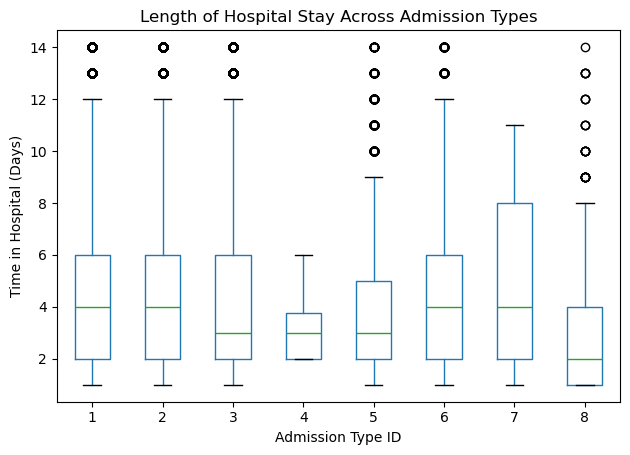

In [199]:
plt.figure(figsize=(10, 6))

df_working.boxplot(
    column="time_in_hospital",
    by="admission_type_id",
    grid=False
)

plt.title("Length of Hospital Stay Across Admission Types")
plt.suptitle("")
plt.xlabel("Admission Type ID")
plt.ylabel("Time in Hospital (Days)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Business Insights — Admission Type vs Length of Hospital Stay

1. Most admission types have a median stay of around 3–4 days. This indicates that the typical hospitalization duration is relatively similar across the major admission categories.

2. Admission Type 7 shows the highest median/typical stay, around 4 days, with many encounters extending toward 8 days. This suggests greater hospitalization duration within this category.

3. Admission Type 4 has the shortest and most concentrated distribution, with most stays around 2–4 days and relatively little variation.

4. Admission Types 1, 2, 3, 5, 6 and 8 show wider variation, including encounters with stays reaching approximately 12–14 days.

5. Long-stay observations appear across multiple admission types. These should not automatically be removed as outliers because they may represent legitimate complex hospitalizations.

## Previous Inpatient Visits vs 30-Day Readmission

In [200]:
inpatient_readmission = (
    df_working.groupby("number_inpatient")["readmitted"]
    .apply(lambda x: (x == "<30").mean() * 100)
    .reset_index(name="readmission_rate")
)

inpatient_readmission

,number_inpatient,readmission_rate
0,0,8.437084
1,1,12.924543
2,2,17.433254
3,3,20.287306
4,4,23.612824
5,5,31.403941
6,6,34.583333
7,7,35.447761
8,8,44.370861
9,9,42.342342


In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    inpatient_readmission["number_inpatient"],
    inpatient_readmission["readmission_rate"]
)

plt.title("30-Day Readmission Rate by Previous Inpatient Visits")
plt.xlabel("Number of Previous Inpatient Visits")
plt.ylabel("30-Day Readmission Rate (%)")

plt.tight_layout()
plt.show()

## Business Insights — Previous Inpatient Visits vs 30-Day Readmission
1. Strong increasing pattern 

The readmission rate generally increases as previous inpatient visits increase:

- 0 visits → 8.44%
- 1 visit → 12.92%
- 2 visits → 17.43%
- 3 visits → 20.29%
- 4 visits → 23.61%
- 5 visits → 31.40%
- 8 visits → 44.37%
- 11 visits → 67.35%

This is a strong business signal.

2. High-utilization patients need greater attention

Patients with repeated previous inpatient visits have substantially higher observed 30-day readmission rates.

This suggests that previous hospitalization history can be used to prioritize patients for care-management resources.

3. The 0-visit group has the lowest observed rate

Patients with no previous inpatient visits have an observed readmission rate of only 8.44%, considerably lower than patients with repeated prior admissions.

4. Very high values need caution

The bars at 15, 17, 19, and 21 visits reaching 100% should not be interpreted as "100% risk."

These categories contain very few encounters, so their percentages can be unstable. This is an important point to mention to your mentor.

5. Direct business opportunity 

The hospital could use previous inpatient utilization as one component of a risk-stratification strategy:

Higher prior inpatient utilization → higher observed readmission rate → potentially higher priority for care-management intervention.

Possible interventions include:

early post-discharge follow-up
medication reconciliation
care-manager contact
outpatient appointment coordination
enhanced discharge planning

### Previous Emergency Visits vs 30-Day Readmission

number_emergency is an important utilization variable in our dataset, and it is stored as an integer. The readmission outcome is still the original readmitted field, so we will calculate the 30-day rate using "<30" rather than creating a new target column at this stage.

### Case Scenario

The hospital wants to determine whether previous emergency-care utilization is associated with 30-day readmission. This can help identify patients with repeated emergency visits who may need closer post-discharge care management.

In [221]:
emergency_readmission = (
    df_working.assign(
        emergency_group=pd.cut(
            df_working["number_emergency"],
            bins=[-1, 0, 1, 2, 4, float("inf")],
            labels=["0", "1", "2", "3-4", "5+"]
        )
    )
    .groupby("emergency_group", observed=False)["readmitted"]
    .apply(lambda x: (x == "<30").mean() * 100)
    .reset_index(name="readmission_rate")
)

emergency_readmission

,emergency_group,readmission_rate
0,0,10.474315
1,1,14.354566
2,2,18.266405
3,3-4,23.839854
4,5+,27.079646


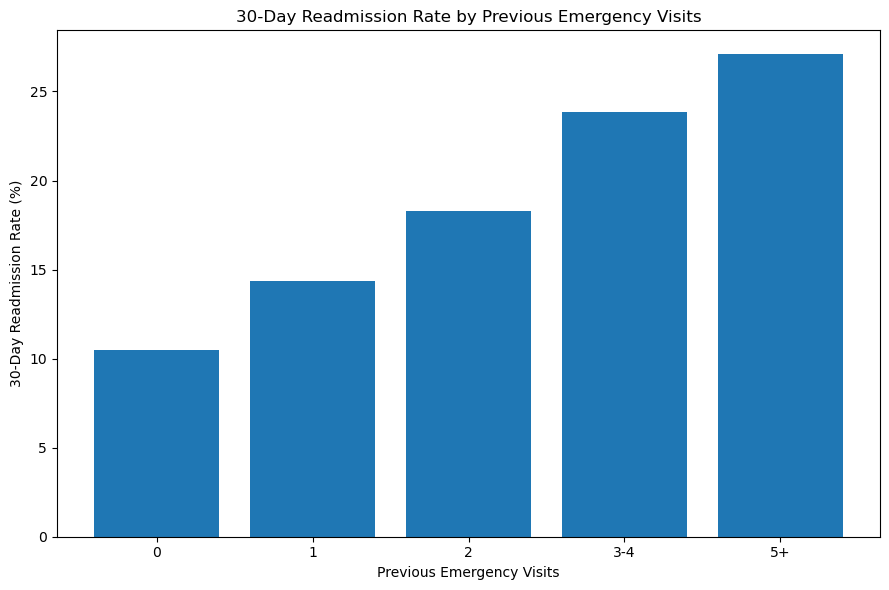

In [222]:
plt.figure(figsize=(9, 6))

plt.bar(
    emergency_readmission["emergency_group"].astype(str),
    emergency_readmission["readmission_rate"]
)

plt.title("30-Day Readmission Rate by Previous Emergency Visits")
plt.xlabel("Previous Emergency Visits")
plt.ylabel("30-Day Readmission Rate (%)")

plt.tight_layout()
plt.show()

#### Business Insights — Previous Emergency Visits vs 30-Day Readmission
Higher previous emergency utilization is consistently associated with higher 30-day readmission: the rate rises from 10.47% for 0 visits to 27.08% for 5+ visits.

Repeated emergency users are a priority care-management segment: patients with frequent prior emergency visits may benefit from closer post-discharge follow-up and care coordination.

### Number of Diagnoses vs 30-Day Readmission
### Case Scenario

The hospital wants to determine whether a higher number of recorded diagnoses is associated with 30-day readmission. This can help identify patients with greater clinical complexity who may require closer follow-up.

In [224]:
diagnosis_readmission = (
    df_working.assign(
        diagnosis_group=pd.cut(
            df_working["number_diagnoses"],
            bins=[0, 3, 6, 9, 12, 16],
            labels=["1-3", "4-6", "7-9", "10-12", "13-16"]
        )
    )
    .groupby("diagnosis_group", observed=False)["readmitted"]
    .apply(lambda x: (x == "<30").mean() * 100)
    .reset_index(name="readmission_rate")
)

diagnosis_readmission

,diagnosis_group,readmission_rate
0,1-3,6.965906
1,4-6,9.442250
2,7-9,12.056808
3,10-12,18.918919
4,13-16,12.820513


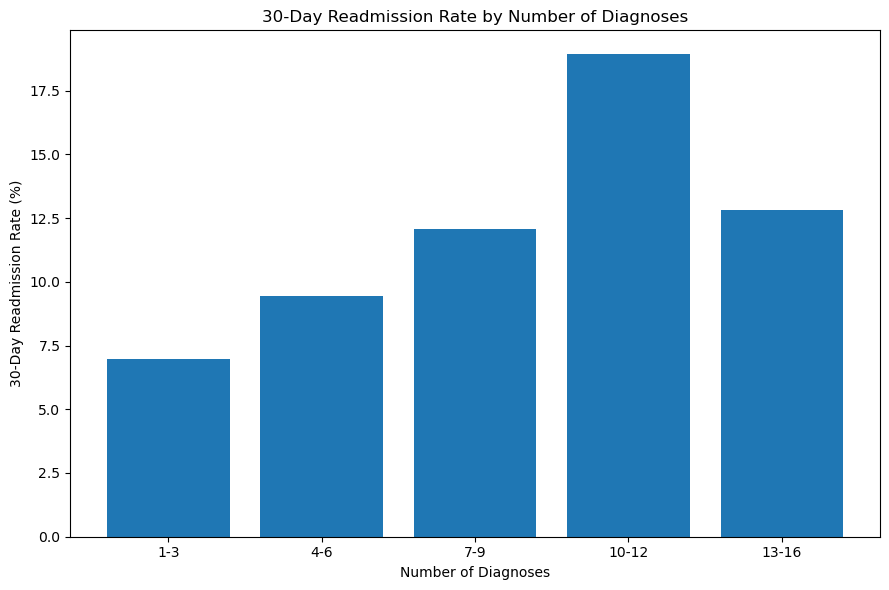

In [225]:
plt.figure(figsize=(9, 6))

plt.bar(
    diagnosis_readmission["diagnosis_group"].astype(str),
    diagnosis_readmission["readmission_rate"]
)

plt.title("30-Day Readmission Rate by Number of Diagnoses")
plt.xlabel("Number of Diagnoses")
plt.ylabel("30-Day Readmission Rate (%)")

plt.tight_layout()
plt.show()

### Business Insights — Number of Diagnoses vs 30-Day Readmission
Readmission generally increases as diagnosis burden increases. The observed rate rises from 6.97% for 1–3 diagnoses to 18.92% for 10–12 diagnoses, indicating that patients with greater recorded clinical complexity are more likely to experience 30-day readmission.

Higher diagnosis burden is a useful risk-stratification signal. Patients with 7 or more diagnoses show noticeably higher readmission rates than the 1–3 diagnosis group, making number_diagnoses a relevant candidate feature for our ML model and for identifying patients who may need closer post-discharge care.

### Length of Hospital Stay vs 30-Day Readmission
### Case Scenario

The hospital wants to determine whether the duration of the current hospital stay is associated with 30-day readmission. This can help identify hospitalization patterns relevant to discharge planning and follow-up.

In [227]:
stay_readmission = (
    df_working.assign(
        stay_group=pd.cut(
            df_working["time_in_hospital"],
            bins=[0, 2, 4, 7, 10, 14],
            labels=["1-2", "3-4", "5-7", "8-10", "11-14"]
        )
    )
    .groupby("stay_group", observed=False)["readmitted"]
    .apply(lambda x: (x == "<30").mean() * 100)
    .reset_index(name="readmission_rate")
)

stay_readmission

,stay_group,readmission_rate
0,1-2,9.143548
1,3-4,11.167929
2,5-7,12.412258
3,8-10,14.103749
4,11-14,12.097210


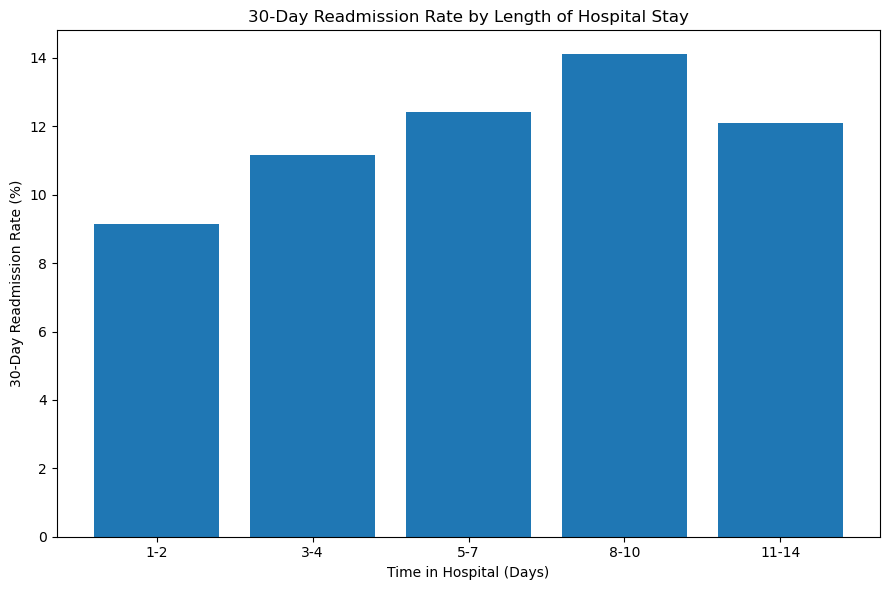

In [228]:
plt.figure(figsize=(9, 6))

plt.bar(
    stay_readmission["stay_group"].astype(str),
    stay_readmission["readmission_rate"]
)

plt.title("30-Day Readmission Rate by Length of Hospital Stay")
plt.xlabel("Time in Hospital (Days)")
plt.ylabel("30-Day Readmission Rate (%)")

plt.tight_layout()
plt.show()

### Business Insights — Length of Hospital Stay vs 30-Day Readmission

1. Readmission generally increases with longer hospital stays. The observed rate rises from 9.14% for 1–2 days to 14.10% for 8–10 days, indicating that longer-stay encounters are associated with higher 30-day readmission.

2. Length of stay is a useful risk signal, but not a simple linear rule. The 11–14 day group drops to 12.10%, so longer stay alone does not continuously increase readmission risk; it should be combined with other patient and clinical factors in the ML model.

### Number of Medications vs 30-Day Readmission
### Case Scenario

The hospital wants to determine whether a higher medication burden is associated with 30-day readmission. This can help identify patients who may require more careful medication management after discharge.

In [229]:
medication_readmission = (
    df_working.assign(
        medication_group=pd.cut(
            df_working["num_medications"],
            bins=[0, 5, 10, 15, 20, float("inf")],
            labels=["1-5", "6-10", "11-15", "16-20", "21+"]
        )
    )
    .groupby("medication_group", observed=False)["readmitted"]
    .apply(lambda x: (x == "<30").mean() * 100)
    .reset_index(name="readmission_rate")
)

medication_readmission

,medication_group,readmission_rate
0,1-5,7.481248
1,6-10,9.449387
2,11-15,10.910700
3,16-20,12.172607
4,21+,12.776382


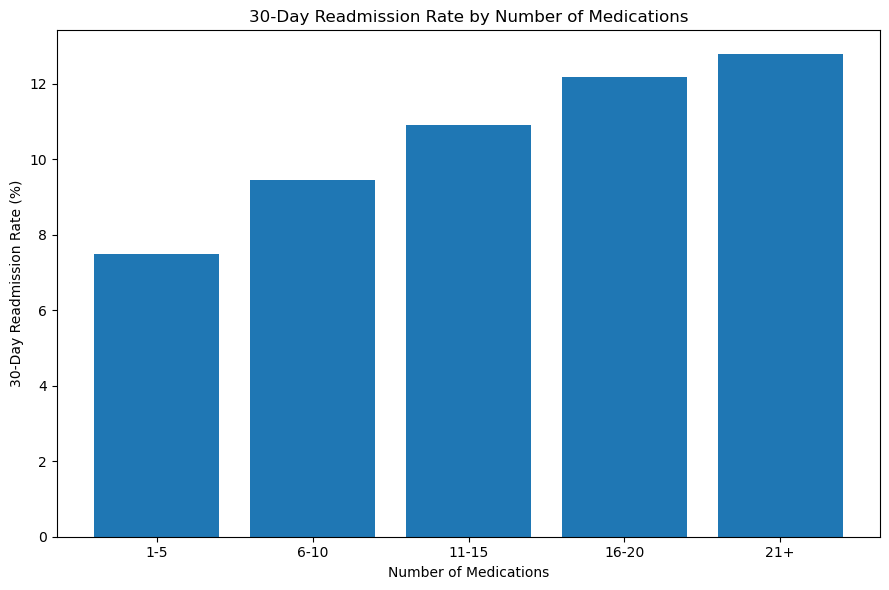

In [230]:
plt.figure(figsize=(9, 6))

plt.bar(
    medication_readmission["medication_group"].astype(str),
    medication_readmission["readmission_rate"]
)

plt.title("30-Day Readmission Rate by Number of Medications")
plt.xlabel("Number of Medications")
plt.ylabel("30-Day Readmission Rate (%)")

plt.tight_layout()
plt.show()

### Business Insights — Number of Medications vs 30-Day Readmission
1. Readmission increases consistently as medication burden increases. The observed rate rises from 7.48% for 1–5 medications to 12.78% for 21+ medications, indicating that patients with higher medication burden show higher observed 30-day readmission.
   
2. Medication burden is a useful candidate risk signal for the ML model. Patients taking larger numbers of medications may require more careful medication reconciliation and post-discharge follow-up, making num_medications relevant for care-management prioritization.

### Previous Outpatient Visits vs 30-Day Readmission
## Case Scenario

The hospital wants to determine whether previous outpatient visits are associated with 30-day readmission. This can help understand whether prior healthcare utilization outside the hospital is related to readmission risk.

In [231]:
outpatient_readmission = (
    df_working.assign(
        outpatient_group=pd.cut(
            df_working["number_outpatient"],
            bins=[-1, 0, 1, 2, float("inf")],
            labels=["0", "1", "2", "3+"]
        )
    )
    .groupby("outpatient_group", observed=False)["readmitted"]
    .apply(lambda x: (x == "<30").mean() * 100)
    .reset_index(name="readmission_rate")
)

outpatient_readmission

,outpatient_group,readmission_rate
0,0,10.674256
1,1,13.923014
2,2,13.745131
3,3+,12.983906


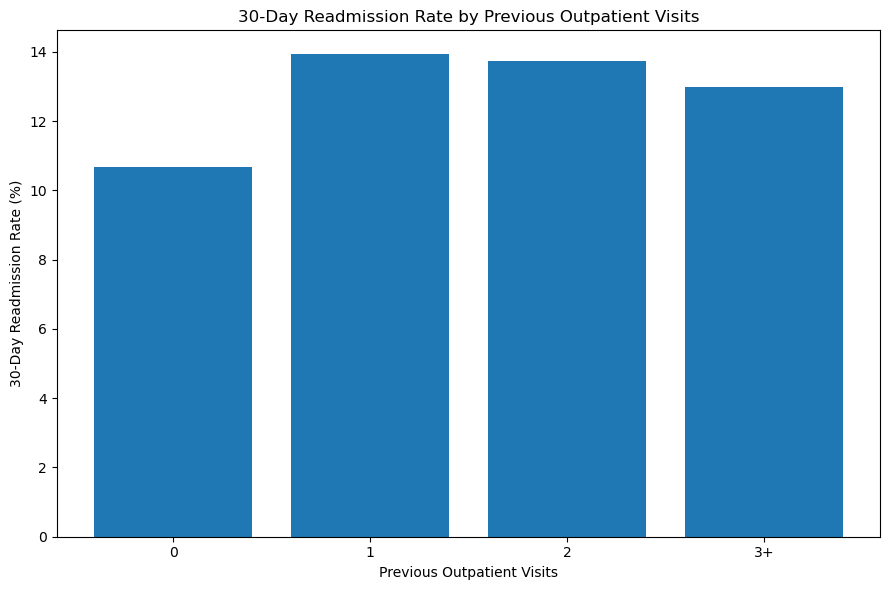

In [232]:
plt.figure(figsize=(9, 6))

plt.bar(
    outpatient_readmission["outpatient_group"].astype(str),
    outpatient_readmission["readmission_rate"]
)

plt.title("30-Day Readmission Rate by Previous Outpatient Visits")
plt.xlabel("Previous Outpatient Visits")
plt.ylabel("30-Day Readmission Rate (%)")

plt.tight_layout()
plt.show()

### Business Insights — Previous Outpatient Visits vs 30-Day Readmission

1. Patients with at least one previous outpatient visit have a higher observed readmission rate than patients with no previous outpatient visits: 10.67% for 0 visits versus 13.92% for 1 visit. This suggests prior outpatient utilization may carry some readmission-risk information.
   
2. The relationship is weaker than the inpatient and emergency-utilization patterns. Readmission stays around 13–14% across the 1, 2, and 3+ groups rather than continuing to increase, so number_outpatient is a moderate/secondary ML candidate rather than one of our strongest signals.

### Number of Lab Procedures vs 30-Day Readmission
### Case Scenario

The hospital wants to determine whether the number of laboratory procedures performed during an encounter is associated with 30-day readmission. This can help understand whether greater investigation intensity is related to readmission.

In [233]:
lab_readmission = (
    df_working.assign(
        lab_group=pd.cut(
            df_working["num_lab_procedures"],
            bins=[0, 30, 60, 90, float("inf")],
            labels=["1-30", "31-60", "61-90", "91+"]
        )
    )
    .groupby("lab_group", observed=False)["readmitted"]
    .apply(lambda x: (x == "<30").mean() * 100)
    .reset_index(name="readmission_rate")
)

lab_readmission

,lab_group,readmission_rate
0,1-30,10.102888
1,31-60,11.346518
2,61-90,11.954919
3,91+,10.304450


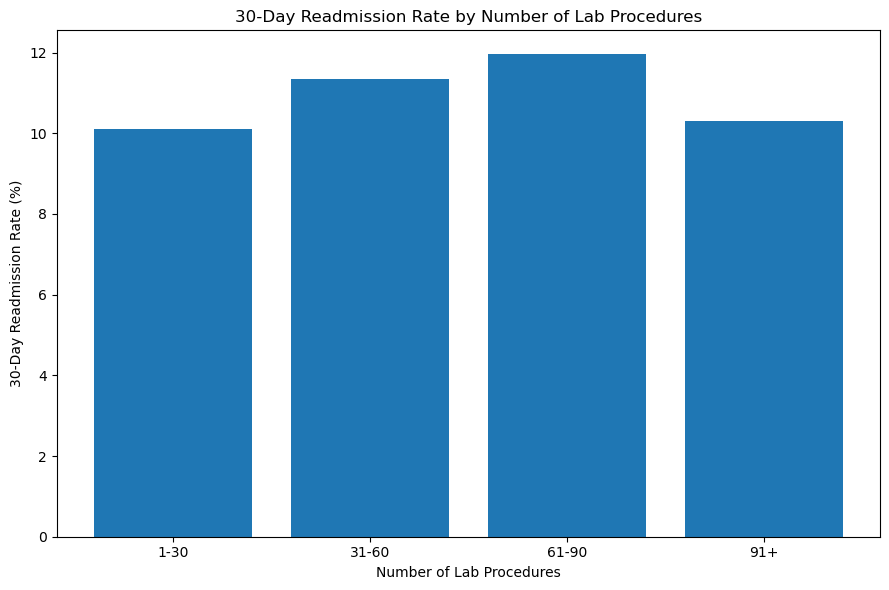

In [234]:
plt.figure(figsize=(9, 6))

plt.bar(
    lab_readmission["lab_group"].astype(str),
    lab_readmission["readmission_rate"]
)

plt.title("30-Day Readmission Rate by Number of Lab Procedures")
plt.xlabel("Number of Lab Procedures")
plt.ylabel("30-Day Readmission Rate (%)")

plt.tight_layout()
plt.show()

### Business Insights — Number of Lab Procedures vs 30-Day Readmission

1. Readmission rises modestly with laboratory-procedure volume up to 61–90 procedures, increasing from 10.10% (1–30) to 11.95% (61–90). This suggests that moderate increases in investigation intensity are associated with a small increase in observed readmission.
   
2. The relationship is weak compared with our stronger utilization features. The 91+ group falls back to 10.30%, so num_lab_procedures is a secondary ML candidate rather than a major readmission-risk signal.

### Number of Procedures vs 30-Day Readmission

### Case Scenario

The hospital wants to understand whether the number of procedures performed during the current encounter is associated with 30-day readmission. This helps assess whether procedure intensity provides useful information for readmission-risk assessment.

In [235]:
procedure_readmission = (
    df_working.groupby("num_procedures")["readmitted"]
    .apply(lambda x: (x == "<30").mean() * 100)
    .reset_index(name="readmission_rate")
)

procedure_readmission

,num_procedures,readmission_rate
0,0,11.077767
1,1,12.207116
2,2,11.181883
3,3,10.685164
4,4,11.028708
5,5,9.421702
6,6,9.588212


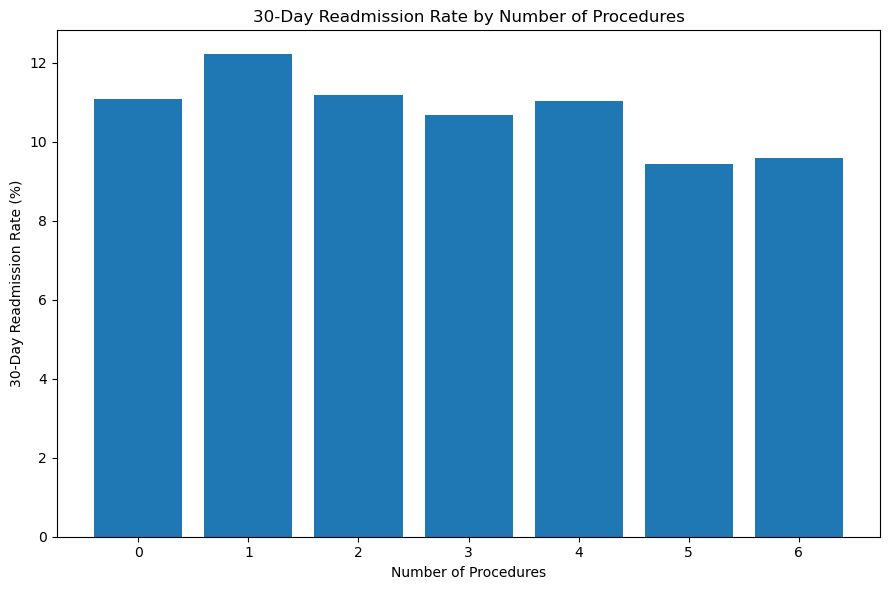

In [236]:
plt.figure(figsize=(9, 6))

plt.bar(
    procedure_readmission["num_procedures"],
    procedure_readmission["readmission_rate"]
)

plt.title("30-Day Readmission Rate by Number of Procedures")
plt.xlabel("Number of Procedures")
plt.ylabel("30-Day Readmission Rate (%)")

plt.tight_layout()
plt.show()

### Business Insights — Number of Procedures vs 30-Day Readmission

1. There is no clear increasing relationship between number of procedures and 30-day readmission. The observed rate varies from 9.42% to 12.21%, with the highest rate at 1 procedure (12.21%).
2. num_procedures appears to be a weaker readmission signal compared with variables such as previous inpatient and emergency visits. It may still be retained as supporting information, but it is unlikely to be one of the strongest business drivers from this analysis.

#### Age Group vs 30-Day Readmission
## Case Scenario

The hospital wants to identify whether 30-day readmission rates differ across patient age groups. This can help identify age segments that may require additional post-discharge support.

In [237]:
age_readmission = (
    df_working.groupby("age")["readmitted"]
    .apply(lambda x: (x == "<30").mean() * 100)
    .reset_index(name="readmission_rate")
)

age_readmission

,age,readmission_rate
0,[0-10),1.863354
1,[10-20),5.788712
2,[20-30),14.242607
3,[30-40),11.231788
4,[40-50),10.604027
5,[50-60),9.666203
6,[60-70),11.128408
7,[70-80),11.773055
8,[80-90),12.083503
9,[90-100),11.099177


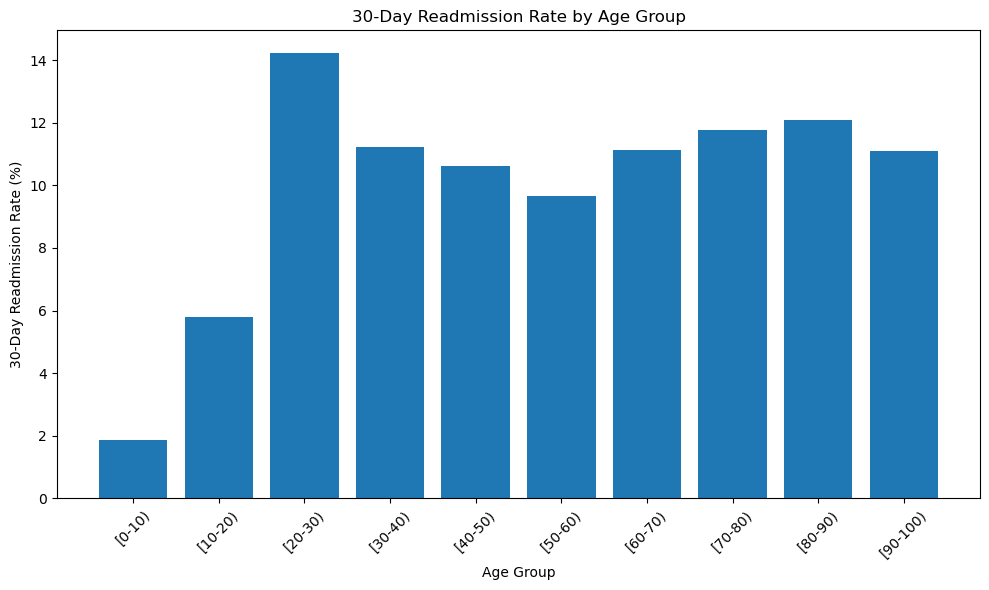

In [238]:
plt.figure(figsize=(10, 6))

plt.bar(
    age_readmission["age"],
    age_readmission["readmission_rate"]
)

plt.title("30-Day Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("30-Day Readmission Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Business Insights — Age Group vs 30-Day Readmission

1. The 20–30 age group has the highest observed 30-day readmission rate at 14.24%, noticeably above the other age groups. This makes this age segment worth investigating further when identifying readmission-risk patterns.
2. Readmission rates are relatively similar across most older age groups, generally around 10–12%, so age alone does not show a simple increasing pattern with readmission in this dataset. age is therefore a useful supporting feature rather than one of our strongest standalone predictors.

### Medical Specialty vs 30-Day Readmission
### Case Scenario

The hospital wants to identify whether 30-day readmission rates differ across major medical specialties. This can help identify specialties that may require greater care-management attention.

In [239]:
top_specialties = (
    df_working["medical_specialty"]
    .value_counts()
    .head(10)
    .index
)

specialty_readmission = (
    df_working[
        df_working["medical_specialty"].isin(top_specialties)
    ]
    .groupby("medical_specialty")["readmitted"]
    .apply(lambda x: (x == "<30").mean() * 100)
    .sort_values()
    .reset_index(name="readmission_rate")
)

specialty_readmission

,medical_specialty,readmission_rate
0,Orthopedics-Reconstructive,7.461476
1,Cardiology,7.940957
2,Radiologist,9.035088
3,Orthopedics,10.785714
4,Surgery-General,11.035818
5,Emergency/Trauma,11.183080
6,InternalMedicine,11.247011
7,?,11.573805
8,Family/GeneralPractice,11.868280
9,Nephrology,15.375077


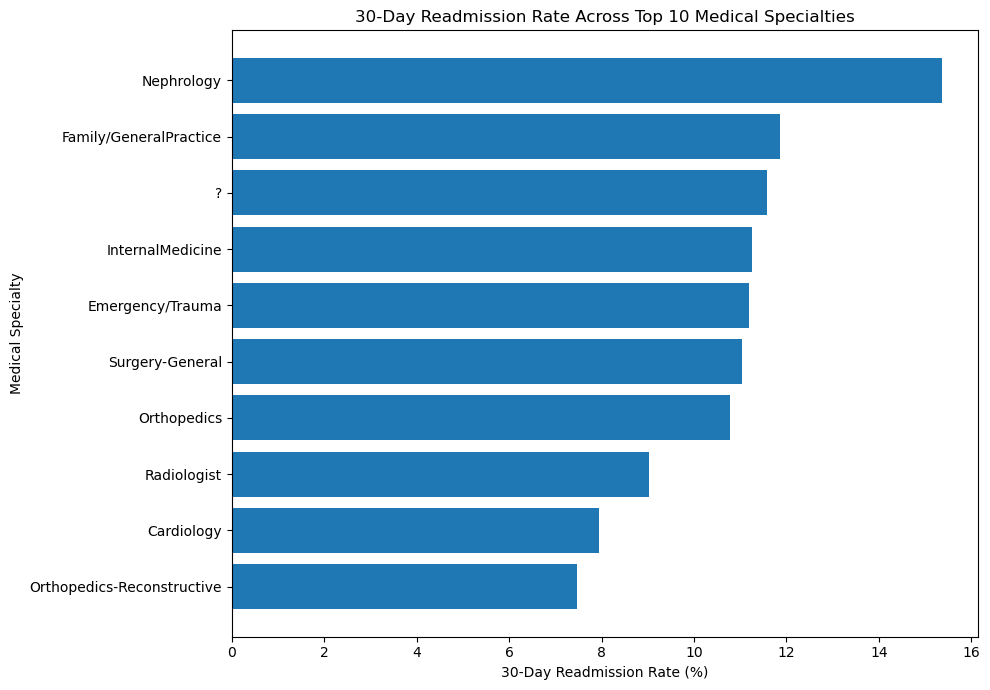

In [240]:
plt.figure(figsize=(10, 7))

plt.barh(
    specialty_readmission["medical_specialty"],
    specialty_readmission["readmission_rate"]
)

plt.title("30-Day Readmission Rate Across Top 10 Medical Specialties")
plt.xlabel("30-Day Readmission Rate (%)")
plt.ylabel("Medical Specialty")

plt.tight_layout()
plt.show()

## Business Insights — Medical Specialty vs 30-Day Readmission
1.Nephrology has the highest observed 30-day readmission rate at 15.38%, making it the most prominent specialty-level risk signal among the top 10 specialties analyzed.

2.Readmission rates vary considerably across specialties—from 7.46% in Orthopedics-Reconstructive to 15.38% in Nephrology—so medical_specialty can provide useful supporting information for readmission-risk stratification and care-management planning.

### Admission Type vs 30-Day Readmission
### Case Scenario

The hospital wants to determine whether the patient's admission pathway is associated with 30-day readmission. This can help identify admission types that may require closer care-management attention.

In [241]:
admission_readmission = (
    df_working.groupby("admission_type_id")["readmitted"]
    .apply(lambda x: (x == "<30").mean() * 100)
    .reset_index(name="readmission_rate")
)

admission_readmission

,admission_type_id,readmission_rate
0,1,11.522504
1,2,11.179654
2,3,10.392708
3,4,10.000000
4,5,10.344828
5,6,11.075411
6,7,0.000000
7,8,8.437500


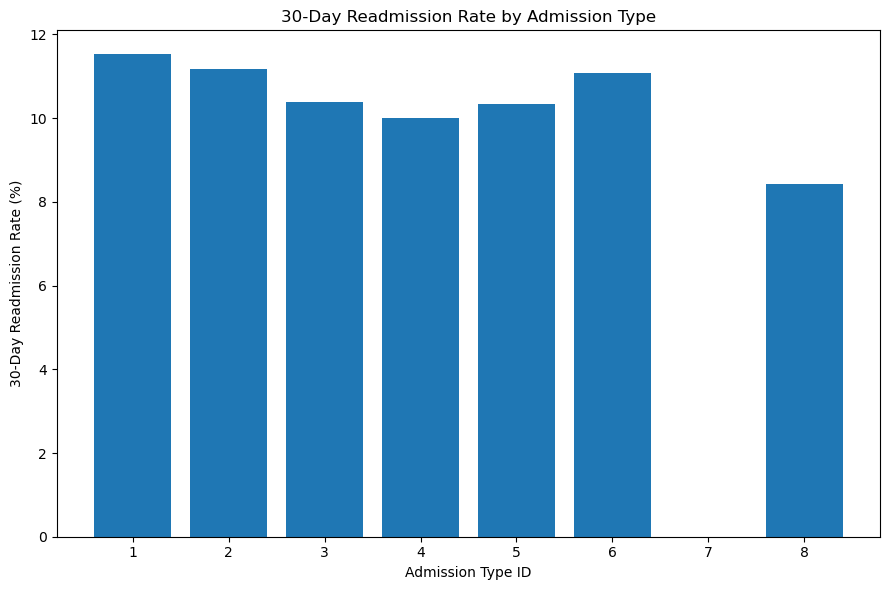

In [242]:
plt.figure(figsize=(9, 6))

plt.bar(
    admission_readmission["admission_type_id"].astype(str),
    admission_readmission["readmission_rate"]
)

plt.title("30-Day Readmission Rate by Admission Type")
plt.xlabel("Admission Type ID")
plt.ylabel("30-Day Readmission Rate (%)")

plt.tight_layout()
plt.show()

### Business Insights — Admission Type vs 30-Day Readmission

1. Readmission rates are fairly similar across the major admission types, ranging from about 10.00% to 11.52% for types 1–6. This suggests admission pathway alone is not a strong standalone readmission driver in this dataset.
2. Emergency admission (Type 1) has the highest observed rate at 11.52%, followed by Urgent (Type 2) at 11.18%. This provides some supporting information for the ML model, but admission_type_id is weaker than variables such as previous inpatient and emergency utilization.

## Maximum Serum Glucose vs 30-Day Readmission
## Case Scenario

The hospital wants to determine whether the recorded maximum serum glucose category is associated with 30-day readmission. This can help identify whether abnormal glucose levels provide useful information for readmission-risk assessment.

In [243]:
glucose_readmission = (
    df_working.groupby("max_glu_serum")["readmitted"]
    .apply(lambda x: (x == "<30").mean() * 100)
    .reset_index(name="readmission_rate")
)

glucose_readmission

,max_glu_serum,readmission_rate
0,>200,12.457912
1,>300,14.319620
2,None,11.093134
3,Norm,11.359261


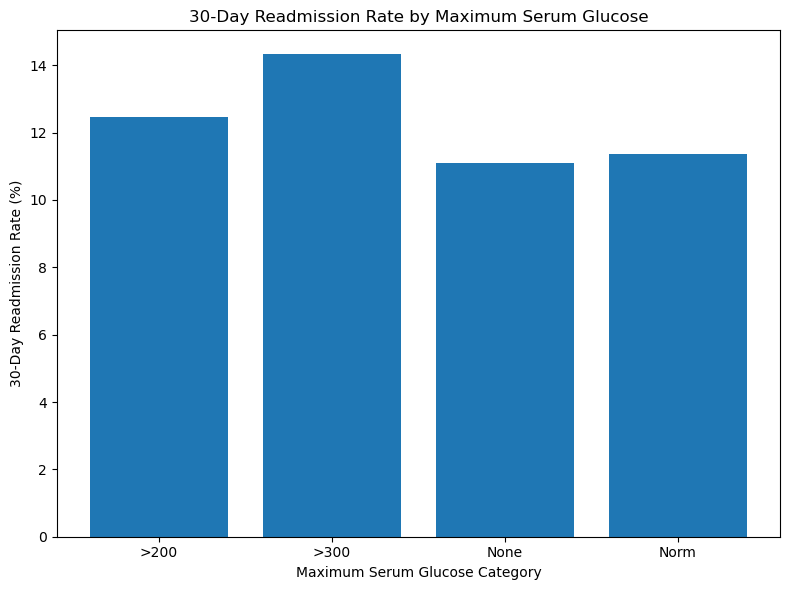

In [244]:
plt.figure(figsize=(8, 6))

plt.bar(
    glucose_readmission["max_glu_serum"].astype(str),
    glucose_readmission["readmission_rate"]
)

plt.title("30-Day Readmission Rate by Maximum Serum Glucose")
plt.xlabel("Maximum Serum Glucose Category")
plt.ylabel("30-Day Readmission Rate (%)")

plt.tight_layout()
plt.show()

### Business Insights — Maximum Serum Glucose vs 30-Day Readmission
1. The >300 glucose category has the highest observed 30-day readmission rate at 14.32%, higher than >200 at 12.46% and the Norm group at 11.36%. This suggests higher recorded glucose levels may provide useful readmission-risk information.
   
2. The glucose signal is moderate rather than strong. The difference between the highest and lowest observed categories is relatively small, so max_glu_serum should be treated as a supporting ML feature, alongside stronger utilization variables such as previous inpatient and emergency visits.

### A1C Result vs 30-Day Readmission
## Case Scenario

The hospital wants to determine whether the recorded A1C result category is associated with 30-day readmission. This can help assess whether evidence of glucose-control status provides useful information for readmission-risk assessment.

A1C_readmission = (
    df_working.groupby("A1Cresult")["readmitted"]
    .apply(lambda x: (x == "<30").mean() * 100)
    .reset_index(name="readmission_rate")
)

A1C_readmission

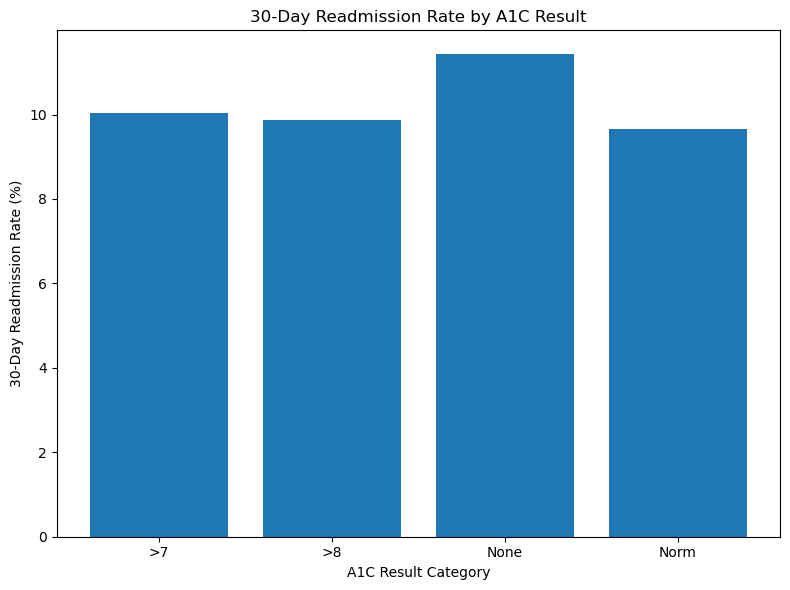

In [246]:
plt.figure(figsize=(8, 6))

plt.bar(
    A1C_readmission["A1Cresult"].astype(str),
    A1C_readmission["readmission_rate"]
)

plt.title("30-Day Readmission Rate by A1C Result")
plt.xlabel("A1C Result Category")
plt.ylabel("30-Day Readmission Rate (%)")

plt.tight_layout()
plt.show()

### Business Insights — A1C Result vs 30-Day Readmission
1. The recorded A1C categories show relatively similar readmission rates. The rates range from 9.66% (Norm) to 10.05% (>7), so there is no strong separation between the recorded A1C groups.
   
2. The None/unrecorded group has the highest observed rate at 11.42%. This means the absence of a recorded A1C result itself may carry useful information, but it should be treated carefully because it reflects missing/unrecorded testing, not necessarily poorer glucose control.

## Insulin Treatment Status vs 30-Day Readmission
## Case Scenario

The hospital wants to determine whether insulin treatment status is associated with 30-day readmission. This can help understand whether treatment changes may identify patients requiring closer post-discharge monitoring.

In [247]:
insulin_readmission = (
    df_working.groupby("insulin")["readmitted"]
    .apply(lambda x: (x == "<30").mean() * 100)
    .reset_index(name="readmission_rate")
)

insulin_readmission

,insulin,readmission_rate
0,Down,13.897528
1,No,10.037355
2,Steady,11.128400
3,Up,12.990456


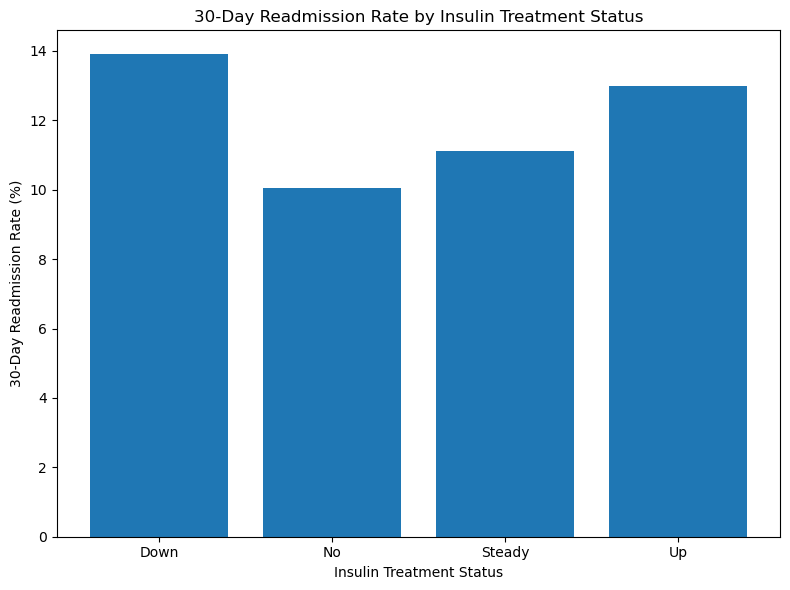

In [248]:
plt.figure(figsize=(8, 6))

plt.bar(
    insulin_readmission["insulin"],
    insulin_readmission["readmission_rate"]
)

plt.title("30-Day Readmission Rate by Insulin Treatment Status")
plt.xlabel("Insulin Treatment Status")
plt.ylabel("30-Day Readmission Rate (%)")

plt.tight_layout()
plt.show()

## Business Insights — Insulin Treatment Status vs 30-Day Readmission

1. Insulin treatment changes are associated with higher observed readmission rates. The Down group has the highest rate at 13.90%, followed by Up at 12.99%, compared with 10.04% for the No insulin group.
2. Insulin status is a useful supporting risk feature, particularly treatment changes. The higher rates for Up and Down suggest that changes in insulin therapy may identify patients who need closer medication review and post-discharge follow-up.

#### Top 10 Business Insights

1. Previous inpatient visits: Higher previous inpatient utilization is strongly associated with higher 30-day readmission.

2. Previous emergency visits: Readmission rates increase consistently as previous emergency visits increase.

3. Number of diagnoses: Patients with more recorded diagnoses show higher observed 30-day readmission rates, indicating greater clinical complexity.

4. Medication burden: Higher numbers of medications are associated with higher observed 30-day readmission rates.

5 .Length of hospital stay: Longer hospital stays generally show higher observed readmission rates, although the relationship is not strictly linear.

6. Medical specialty: Readmission rates differ across specialties, with Nephrology showing the highest observed rate among the top specialties analyzed.

7. Insulin treatment status: Encounters involving insulin treatment changes show higher observed readmission than encounters with no insulin treatment.

8. Maximum serum glucose: Higher glucose categories, particularly >300, show higher observed readmission than the normal category.

9. Previous outpatient visits: Prior outpatient utilization shows a modest association with readmission, but the pattern is weaker than inpatient and emergency utilization.

10. Age group: Readmission rates differ across age groups, but there is no consistent increase with age; therefore, age is a supporting rather than primary business signal.